# GRB and Kilonova Mass-Plane Diagnostics

Gottlieb et al. ([2023](https://arxiv.org/abs/2309.00038), [2024](https://arxiv.org/abs/2411.13657v2)) classification framework applied to COMPAS Model A (Broekgaarden et al. 2021, arXiv:2103.02608) under Planck 2015 ($H_0 = 67.74$ km/s/Mpc, $\Omega_m = 0.3089$) to match COMPAS `FastCosmicIntegration`. Disk-mass GRB rates assume 100 percent jet launching and are upper bounds (Gottlieb 2023).

In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm, LogNorm, to_rgba
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

from grb_physics import (foucart_disk_mass, M_CRIT_BNS, Q_THRESH_BNS,
                          MDISK_SHORT, MDISK_LONG, M_TOV, M_THRESH,
                          EOS_MODELS, mcrit_to_r14,
                          MISALIGNMENT_SYSTEMATIC_FACTOR,
                          effective_aligned_spin, ns_radius_from_eos,
                          remap_ns_masses_double_gaussian,
                          remap_ns_marginal,
                          NS_REMAP_MU1, NS_REMAP_MU2)
from grb_classify import (classify_bns_2023, classify_bns_2024, classify_bhns,
                           classify_grid, classify_formation_channels,
                           bns_boundary_lines)
from grb_rates import (compute_merger_rate, calibrate_mean_mass_evolved,
                        formation_efficiency, marginalize_bh_spin,
                        rate_label,
                        beamed_rate, OBSERVED_SGRB_RATES,
                        wanderman_piran_2015_Rz,
                        check_dPdlogZ_normalization, CLASS_THETA_J,
                        apply_bhns_misalignment)
from grb_io import (load_bns, load_bhns, load_bns_with_channels,
                     load_bhns_with_channels,
                     load_bns_with_kicks, load_bhns_with_kicks,
                     read_expected_local_rate,
                     verify_shared_metallicity_prior,
                     METALLICITY_GRID,
                     OBSERVED_GW_EVENTS,
                     DEFAULT_BNS_PATH, DEFAULT_BHNS_PATH)

# Project palette.
C_SB_BLUE  = '#06B6D4'
C_LB_HMNS  = '#DC2626'
C_LB_DISK  = '#DC2626'
C_FAINT    = '#F59E0B'
C_NO_GRB   = '#334155'
C_FAINT_BH = '#F59E0B'
C_LONG_BH  = '#DC2626'
C_OBS      = '#6B21A8'
C_GUIDE    = '#94A3B8'
C_TEXT     = '#0F172A'
C_BOX_EDGE = '#CBD5E1'

# ApJ rcParams applied globally so every figure inherits the same body
# font, tick style, and serif math.
APJ_RCPARAMS = {
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
    'savefig.format':      'pdf',
    'font.size':           8,
    'font.family':         'serif',
    'mathtext.fontset':    'cm',
    'axes.linewidth':      0.7,
    'axes.labelsize':      9,
    'axes.titlesize':      9,
    'xtick.labelsize':     7,
    'ytick.labelsize':     7,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'legend.fontsize':     7,
    'legend.frameon':      True,
    'legend.framealpha':   0.92,
    'lines.linewidth':     1.0,
}
plt.rcParams.update(APJ_RCPARAMS)

A_BH_FID = 0.5
M_HMNS_SPLIT = 1.2 * M_TOV

# COMPAS Model A maximum NS gravitational mass (Broekgaarden+ 2021,
# arXiv:2103.02608; their fiducial M_NS_max = 2.5 Msun, Models J/K = 2.0/3.0).
NS_MAX_BNS = 2.5

# Mass-plane shared plot constants. GRID_COLORS is indexed by classify_grid
# integer labels (0 = unclassified, 1-6 see grb_classify.GRID_CLASS_LABELS).
cmap_hex   = 'Greys'
grid_colors = [C_NO_GRB, C_FAINT, C_LB_HMNS, C_SB_BLUE, C_LB_DISK,
               C_FAINT_BH, C_LONG_BH]
norm_grid  = BoundaryNorm(np.arange(-0.5, 7.5, 1), len(grid_colors))
TINT_ALPHA = 0.22
cmap_grid_tint = ListedColormap(
    [to_rgba(c, 0.0 if c == C_NO_GRB else TINT_ALPHA) for c in grid_colors])

# Load BNS (with channels + kicks for later sections).
bns_ch = load_bns_with_channels()
bns_k  = load_bns_with_kicks()

# Apply Alsing, Silva and Berti (2018) double-Gaussian remap globally so every
# downstream BNS figure and rate sees the same masses.
_m1_raw_bns, _m2_raw_bns = bns_ch['m1'].copy(), bns_ch['m2'].copy()
bns_ch['m1'], bns_ch['m2'] = remap_ns_masses_double_gaussian(
    _m1_raw_bns, _m2_raw_bns,
    weights=bns_ch['weights'], rng=np.random.default_rng(42))
bns_k['m1'],  bns_k['m2']  = bns_ch['m1'], bns_ch['m2']

m1_bns, m2_bns = bns_ch['m1'], bns_ch['m2']
w_bns     = bns_ch['weights']
Z_bns     = bns_ch['metallicity']
delay_bns = bns_ch['delay_time']
n_bns     = bns_ch['n_merging']
M_tot     = m1_bns + m2_bns
q_bns     = m1_bns / m2_bns

# Vectorized remap diagnostics: stack the two component arrays and count
# raw/remapped systems in the [1.65, 1.80] Msun rapid-engine gap.
gap_lo, gap_hi = 1.65, 1.80
_raw   = np.concatenate([_m1_raw_bns, _m2_raw_bns])
_new   = np.concatenate([m1_bns, m2_bns])
_n_gap = ((_raw >= gap_lo) & (_raw <= gap_hi)).sum()
_n_new = ((_new >= gap_lo) & (_new <= gap_hi)).sum()
print(f"BNS NS-mass remap (Alsing+ 2018):  gap [1.65, 1.80] Msun  "
      f"raw={int(_n_gap):,}  remap={int(_n_new):,}  "
      f"max NS = {_new.max():.3f}  M_TOV = {M_TOV:.2f}")
assert _new.max() <= M_TOV + 1e-6, "remapped NS mass exceeds M_TOV"
assert bool(np.all(m1_bns >= m2_bns)), "m1 >= m2 invariant broken after remap"

# BNS classification.
cls24 = classify_bns_2024(m1_bns, m2_bns)
sbGRB_blue   = cls24['sbGRB + blue KN']
lbGRB_hmns   = cls24['lbGRB + red KN (HMNS)']
lbGRB_disk   = cls24['lbGRB + red KN (disk)']
bns_faint_lb = cls24['Faint lbGRB']

cls23 = classify_bns_2023(m1_bns, m2_bns)
short_typeI_23  = cls23['Short Type-I']
short_typeII_23 = cls23['Short Type-II']
long_cbGRB_23   = cls23['Long cbGRB']

# Load BHNS twice: bhns_ch carries formationChannels columns (Section 8b
# per-channel cosmic integration); bhns_k carries v_sys for the Section 9
# offset analysis.  Both loaders read the same doubleCompactObjects table
# and apply the same mergesInHubbleTimeFlag mask, so per-system ordering is
# identical -- the assert tripwires any future drift between the two loaders.
bhns_ch = load_bhns_with_channels()
bhns_k  = load_bhns_with_kicks()
assert bhns_ch['weights'].shape == bhns_k['weights'].shape, \
    "bhns_ch and bhns_k disagree on n_merging; mergesInHubbleTimeFlag mask drifted"

# Mirror the BNS remap on the BHNS NS component so the 1.7 Msun Fryer 2012
# Eq. 12-13 deficit (Broekgaarden+ 2021 footnote 3) does not propagate into
# Section 1's BHNS panel, Section 8's spin sweep, or any downstream BHNS rate.
# Separate RNG seed from the BNS call so the two populations get independent
# tie-breaking jitter.
_M_NS_raw_bhns = bhns_ch['M_NS'].copy()
bhns_ch['M_NS'] = remap_ns_marginal(
    bhns_ch['M_NS'], weights=bhns_ch['weights'],
    rng=np.random.default_rng(43))
bhns_k['M_NS']  = bhns_ch['M_NS']

_n_gap_bhns_raw = ((_M_NS_raw_bhns >= 1.65) & (_M_NS_raw_bhns <= 1.80)).sum()
_n_gap_bhns_new = ((bhns_ch['M_NS'] >= 1.65) & (bhns_ch['M_NS'] <= 1.80)).sum()
print(f"BHNS NS-mass remap (Alsing+ 2018): gap [1.65, 1.80] Msun  "
      f"raw={int(_n_gap_bhns_raw):,}  remap={int(_n_gap_bhns_new):,}  "
      f"max NS = {bhns_ch['M_NS'].max():.3f}  M_TOV = {M_TOV:.2f}")
assert bhns_ch['M_NS'].max() <= M_TOV + 1e-6, "remapped BHNS NS mass exceeds M_TOV"

BH, NS_bh  = bhns_ch['M_BH'], bhns_ch['M_NS']
w_bhns     = bhns_ch['weights']
Z_bhns     = bhns_ch['metallicity']
delay_bhns = bhns_ch['delay_time']
n_bhns     = bhns_ch['n_merging']

cbhns = classify_bhns(BH, NS_bh, a_BH=A_BH_FID)
M_disk_bhns   = cbhns['M_disk']
bhns_no_grb   = cbhns['No GRB']
bhns_faint_lb = cbhns['Short cbGRB']
bhns_long     = cbhns['Long cbGRB']

v_sys_bns  = bns_k['v_sys']
v_sys_bhns = bhns_k['v_sys']

# Vectorized class summary: mask matrix (n_class, N) -> weighted counts.
def _summary(name, masks_dict, w, n):
    arr = np.stack(list(masks_dict.values()))
    counts = (arr * w).sum(-1) / w.sum() * 100
    raw    = arr.sum(-1)
    print(f"\n{name}: {n:,} merging systems")
    for (lbl, _), pct, n_raw in zip(masks_dict.items(), counts, raw):
        print(f"  {lbl:38s}: {int(n_raw):>7,}  ({pct:.1f}% weighted)")

_summary('BNS', {
    'sbGRB + blue KN (long-lived HMNS)':    sbGRB_blue,
    'lbGRB + red KN  (short-lived HMNS)':   lbGRB_hmns,
    'lbGRB + red KN  (massive disk)':       lbGRB_disk,
    'Faint lbGRB    (small disk / prompt)': bns_faint_lb,
}, w_bns, n_bns)

_summary(f'BHNS (a_BH = {A_BH_FID})', {
    'lbGRB + red KN (massive disk)': bhns_long,
    'Faint lbGRB    (small disk)':   bhns_faint_lb,
    'No GRB / KN    (NS swallowed)': bhns_no_grb,
}, w_bhns, n_bhns)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
BNS NS-mass remap (Alsing+ 2018):  gap [1.65, 1.80] Msun  raw=21,589  remap=36,280  max NS = 2.200  M_TOV = 2.20
BHNS NS-mass remap (Alsing+ 2018): gap [1.65, 1.80] Msun  raw=137,766  remap=155,113  max NS = 2.200  M_TOV = 2.20

BNS: 233,137 merging systems
  sbGRB + blue KN (long-lived HMNS)     :  52,660  (24.0% weighted)
  lbGRB + red KN  (short-lived HMNS)    :  87,852  (26.8% weighted)
  lbGRB + red KN  (massive disk)        :   2,614  (2.2% weighted)
  Faint lbGRB    (small disk / prompt)  :  90,011  (47.0% weighted)

BHNS (a_BH = 0.5): 1,525,553 merging systems
  lbGRB + red KN (massive disk)         :   7,573  (3.8% weighted)
  Faint lbGRB    (small disk)           : 125,479  (20.6% weighted)
  No GRB / KN    (NS swallowed)         : 1,392,501  (75.6% weighted)


/Users/josephrodriguez/research visualization/grb_physics.py:709: UserWarning: Foucart (2018) formula applied to 959368 systems with Q > 7 (max Q=29.4); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(


## 1. Mass Plane, BNS and BHNS

$M_1$ vs $M_2$ for COMPAS Model A. BHNS uses Foucart, Hinderer and Nissanke (2018, PRD 98, 081501) disk-mass classes at $a_\mathrm{BH} = 0.5$; BNS reproduces and extends Gottlieb et al. (2024, Fig. 3). Filled cividis KDE: STROOPWAFEL-weighted density of the full merging population (no subsampling). Tints: classification regions. Contours: boundaries.

/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_76268/860509553.py:15: UserWarning: classify_grid: R_1p4_km not specified; BHNS branch inherits foucart_disk_mass default R_1p4_km=12.0 km, so class 6 (lbGRB + red KN, massive disk) is implicitly EOS-dependent.  Pass R_1p4_km explicitly (e.g. EOS_MODELS['SFHo']['R_1p4']) to suppress this warning.
  cls_bhns = classify_grid(M1G_bhns, M2G_bhns, a_bh=A_BH_FID, ns_max=NS_MAX_BNS)
/Users/josephrodriguez/research visualization/grb_physics.py:709: UserWarning: Foucart (2018) formula applied to 160629 systems with Q > 7 (max Q=14.4); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(
/Users/josephrodriguez/research visualization/grb_physics.py:709: UserWarning: Foucart (2018) formula applied to 34606 systems with Q > 7 (max Q=20.0); calibrated for Q in [1, 7]
  M_rem = foucart_remnant_mass(


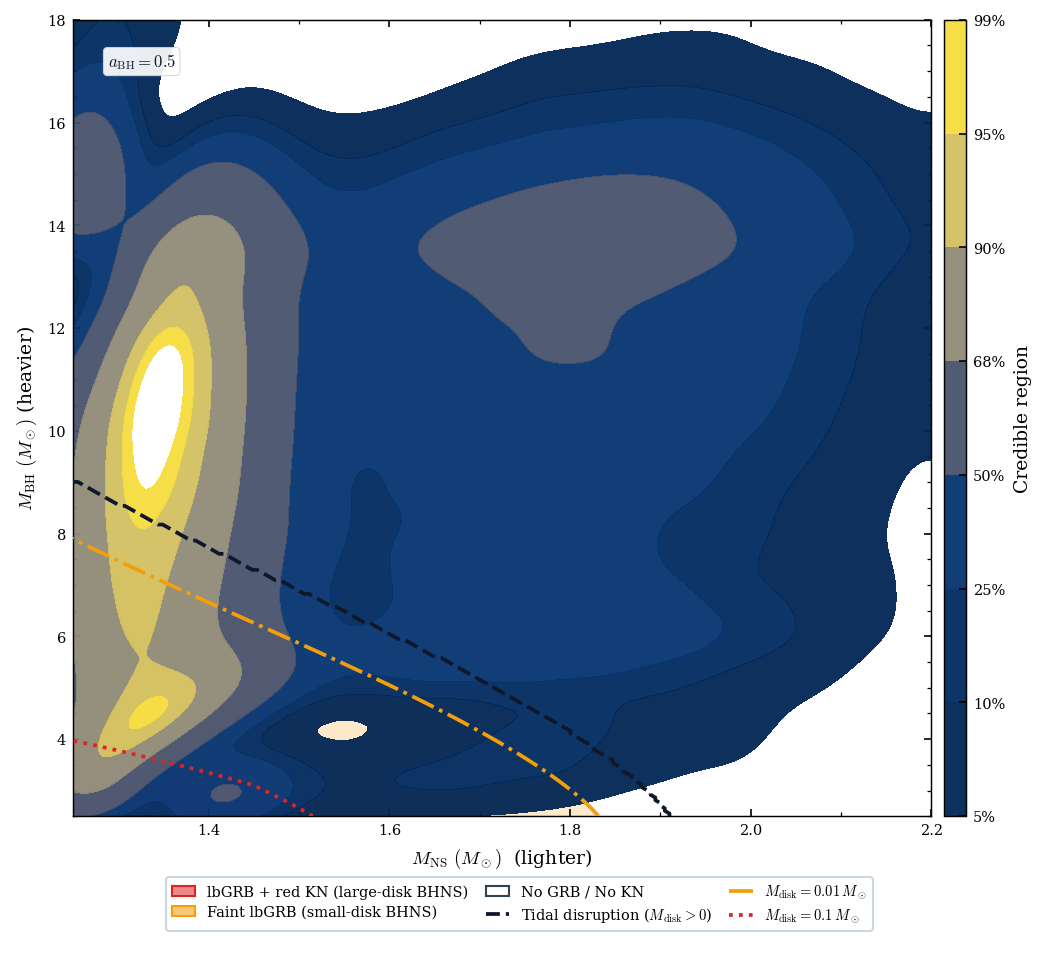

BHNS panel sample: raw N = 1,525,553, Kish N_eff = 292,484


In [11]:
# BHNS classification grid (faint underlay).  M2_HI snaps to NS_MAX_BNS so
# the panel ends where the BNS/BHNS boundary actually is (matches the COMPAS
# Model A M_NS_max = 2.5 Msun configuration).  M1_LO at 2.5 Msun shows the
# lower BH mass gap honestly (Bailyn et al. 1998; Farr et al. 2011; reviewed
# in Abbott+ 2020, GW190814).  M1_HI snaps just above the outermost 99%-
# enclosure KDE contour for the weighted BHNS population (p99.5 of M_BH in
# Model A is 20.1 Msun; the contour itself tops out near 14 Msun) so the
# panel focuses on the populated region rather than the long high-mass tail.
M2_LO_BHNS, M2_HI_BHNS = 1.25, 2.2
M1_LO_BHNS, M1_HI_BHNS = 2.5, 18.0

m2_arr_bhns = np.linspace(M2_LO_BHNS, M2_HI_BHNS, 700)
m1_arr_bhns = np.linspace(M1_LO_BHNS, M1_HI_BHNS, 600)
M2G_bhns, M1G_bhns = np.meshgrid(m2_arr_bhns, m1_arr_bhns)
cls_bhns = classify_grid(M1G_bhns, M2G_bhns, a_bh=A_BH_FID, ns_max=NS_MAX_BNS)
cls_bhns_masked = np.ma.array(cls_bhns, mask=(M2G_bhns < 0.8))

# Foucart (2018) disk-mass contours for the boundary lines.
_MBH_c = np.linspace(M1_LO_BHNS, M1_HI_BHNS, 300)
_MNS_c = np.linspace(0.9, M2_HI_BHNS, 250)
_MNSg, _MBHg = np.meshgrid(_MNS_c, _MBH_c)
_disk_g = foucart_disk_mass(_MBHg, _MNSg, a_BH=A_BH_FID)
_dg_safe = np.where(_disk_g > 0, _disk_g, np.nan)

fig_bhns = plt.figure(figsize=(7.0, 6.8))
gs = GridSpec(2, 2, height_ratios=[1, 0.11],
              width_ratios=[1, 0.025], hspace=0.10, wspace=0.03,
              figure=fig_bhns,
              left=0.10, right=0.95, top=0.97, bottom=0.06)
ax  = fig_bhns.add_subplot(gs[0, 0])
cax = fig_bhns.add_subplot(gs[0, 1])
lax = fig_bhns.add_subplot(gs[1, :])
lax.axis('off')

ax.pcolormesh(m2_arr_bhns, m1_arr_bhns, cls_bhns_masked,
              cmap=cmap_grid_tint, norm=norm_grid, shading='nearest',
              rasterized=True, zorder=0)

# Reflective-boundary KDE at the M_NS = M_TOV hard wall.  The Alsing
# remap caps the BHNS NS distribution at M_TOV exactly (assert above);
# a naive KDE would smear density past 2.2 Msun.  Silverman (1986,
# Sec. 2.10) prescribes mirroring the data across the wall and
# evaluating on the physical side; for a Gaussian (symmetric) kernel
# this is identically equivalent to evaluating the unmirrored KDE at
# both (x, y) and (2*M_TOV - x, y) and summing.  The dual-evaluation
# form keeps the bandwidth tied to the actual population covariance
# (mirroring the data inflates the M_NS variance and would over-
# smooth in that direction).  Same construction used in compact-binary
# population work, e.g. Talbot and Thrane (2018), Mandel, Farr and
# Gair (2019).  Silverman's rule via scipy uses the Kish effective
# sample size N_eff = 1 / sum(w_norm^2) for the bandwidth scaling.
from scipy.stats import gaussian_kde

_kde = gaussian_kde(np.vstack([NS_bh, BH]),
                    weights=w_bhns, bw_method='silverman')

_ns_grid = np.linspace(M2_LO_BHNS, M_TOV, 180)
_bh_grid = np.linspace(M1_LO_BHNS, M1_HI_BHNS, 160)
_NSg, _BHg = np.meshgrid(_ns_grid, _bh_grid)
_pts      = np.vstack([_NSg.ravel(),               _BHg.ravel()])
_pts_refl = np.vstack([2.0 * M_TOV - _NSg.ravel(), _BHg.ravel()])
_Z = (_kde(_pts) + _kde(_pts_refl)).reshape(_NSg.shape)

# Quantile-based contour levels: each band encloses the labelled
# cumulative fraction of the weighted KDE mass.  Standard compact-
# binary mass-plane convention (Talbot and Thrane 2018 Sec. 2.3;
# GWTC-3, Abbott et al. 2023).  Equal-spaced density levels would
# pack all 12 bands into the Alsing peak and leave the rest of the
# panel uninformative.
_quantiles = np.array([0.05, 0.10, 0.25, 0.50, 0.68, 0.90, 0.95, 0.99])

def _quantile_levels(Z, quantiles):
    flat = Z.compressed() if hasattr(Z, 'compressed') else Z.ravel()
    s = np.sort(flat)[::-1]
    c = np.cumsum(s) / s.sum()
    return sorted(s[np.searchsorted(c, q)] for q in quantiles)

_levels = _quantile_levels(_Z, _quantiles)

hb_bh = ax.contourf(_NSg, _BHg, _Z, levels=_levels,
                    cmap='cividis', alpha=0.95, zorder=2)

ax.contour(_MNSg, _MBHg, (_disk_g > 0).astype(float), levels=[0.5],
           colors=C_TEXT, linewidths=1.8, linestyles='--', zorder=4)
ax.contour(_MNSg, _MBHg, _dg_safe, levels=[MDISK_SHORT, MDISK_LONG],
           colors=[C_FAINT, C_LB_DISK], linewidths=1.8,
           linestyles=['-.', ':'], zorder=4)

ax.text(0.04, 0.96, rf'$a_{{\mathrm{{BH}}}} = {A_BH_FID}$',
        color=C_TEXT, transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.25', fc='white',
                  ec=C_BOX_EDGE, alpha=0.92, lw=0.5))

ax.set_xlabel(r'$M_\mathrm{NS}\ (M_\odot)$  (lighter)')
ax.set_ylabel(r'$M_\mathrm{BH}\ (M_\odot)$ (heavier)')
ax.set_xlim(M2_LO_BHNS, M2_HI_BHNS)
ax.set_ylim(M1_LO_BHNS, M1_HI_BHNS)
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_axisbelow(True)

_pa = 0.55
handles = [
    Patch(fc=to_rgba(C_LONG_BH, _pa), ec=C_LONG_BH, lw=1.0,
          label='lbGRB + red KN (large-disk BHNS)'),
    Patch(fc=to_rgba(C_FAINT_BH, _pa), ec=C_FAINT_BH, lw=1.0,
          label='Faint lbGRB (small-disk BHNS)'),
    Patch(fc='white', ec=C_NO_GRB, lw=1.0, label='No GRB / No KN'),
    Line2D([0], [0], color=C_TEXT, lw=1.8, ls='--',
           label=r'Tidal disruption ($M_\mathrm{disk} > 0$)'),
    Line2D([0], [0], color=C_FAINT, lw=1.8, ls='-.',
           label=r'$M_\mathrm{disk} = 0.01\,M_\odot$'),
    Line2D([0], [0], color=C_LB_DISK, lw=1.8, ls=':',
           label=r'$M_\mathrm{disk} = 0.1\,M_\odot$'),
]
lax.legend(handles=handles, loc='center', ncol=3,
           frameon=True, fancybox=True, edgecolor=C_BOX_EDGE,
           facecolor='white', framealpha=0.95,
           handlelength=1.6, columnspacing=1.2, labelspacing=0.4,
           borderaxespad=0.0)

cb = fig_bhns.colorbar(hb_bh, cax=cax)
cb.set_ticks(_levels)
cb.set_ticklabels([f'{int(q*100)}%' for q in _quantiles])
cb.set_label('Credible region')

fig_bhns.savefig('Plots/mass_plane_bhns.png', dpi=300)
fig_bhns.savefig('Plots/mass_plane_bhns.pdf')
plt.show()

_n_bhns_raw = int(NS_bh.size)
_n_bhns_eff = (w_bhns.sum() ** 2) / (w_bhns ** 2).sum()
print(f'BHNS panel sample: raw N = {_n_bhns_raw:,}, '
      f'Kish N_eff = {_n_bhns_eff:,.0f}')


**BHNS mass plane (Section 1 supporting panel).** Foucart, Hinderer and Nissanke (2018) disk-mass classes at $a_\mathrm{BH} = 0.5$.

- Sample: raw $N = 1{,}525{,}553$ merging BHNS systems; Kish effective $N_\mathrm{eff} = (\sum w)^2 / \sum w^2 = 292{,}484$. Full COMPAS Model A merging population (Broekgaarden et al. 2021, Zenodo 5189849), STROOPWAFEL-weighted, no subsampling.
- Filled KDE: STROOPWAFEL-weighted density over the full merging BHNS sample, contoured at the cumulative-fraction levels 5, 10, 25, 50, 68, 90, 95, 99 percent (cividis; colorbar tick labels are the fraction of the weighted population enclosed by each contour, Talbot and Thrane 2018 Sec. 2.3; GWTC-3, Abbott et al. 2023). Reflective-boundary KDE at $M_\mathrm{NS} = M_\mathrm{TOV} = 2.2\,M_\odot$ (Silverman 1986, Sec. 2.10): density evaluated as $f(x) + f(2 M_\mathrm{TOV} - x)$ on the physical side, identically the mirror trick for symmetric kernels. Bandwidth: Silverman's rule on the unmirrored sample via `scipy.stats.gaussian_kde(bw_method='silverman')`, weights pass through directly with $N_\mathrm{eff} = 1 / \sum w_\mathrm{norm}^2$.
- Tints: red lbGRB + red KN ($M_\mathrm{disk} \geq 0.1\,M_\odot$); amber Faint lbGRB ($0.01 \leq M_\mathrm{disk} < 0.1\,M_\odot$); No GRB untinted.
- Boundaries: dashed dark $M_\mathrm{disk} > 0$ (tidal-disruption locus); dash-dot amber $M_\mathrm{disk} = 0.01\,M_\odot$; dotted red $M_\mathrm{disk} = 0.1\,M_\odot$. Foucart-2018 contours computed with $R_{1.4} = 12\,\mathrm{km}$ (Raaijmakers et al. 2021, $R_{1.4} = 12.18^{+0.56}_{-0.79}\,\mathrm{km}$ CS model); EOS-conditional contours appear in the Section 11 sweep.
- BH lower mass gap: panel extends to $M_\mathrm{BH} = 2.5\,M_\odot$ to show the gap (Bailyn et al. 1998; Farr et al. 2011; GW190814, Abbott et al. 2020). Model A uses the Fryer et al. (2012) *delayed* engine (Broekgaarden+ 2021 Table 1), which partially fills the 2.5-5 $M_\odot$ region, unlike the *rapid* variant that imposes a clean wall at $5\,M_\odot$ (Fryer 2012 fig. 4). Upper $M_\mathrm{BH}$ limit set to $18\,M_\odot$ to focus on the populated region; the long high-mass tail (p99.5 $\approx 20\,M_\odot$, max $\approx 39\,M_\odot$) lies above the outermost 99 percent KDE contour.
- Caveats: Foucart (2018) calibrated for $\chi_\mathrm{BH} \in [-0.5, 0.9]$, $Q \in [1, 7]$; high-$Q$ systems in the figure fall in the no-disruption regime and are not affected. Coloured classification regions assume 100 % jet launching above the disk-mass threshold (Gottlieb et al. 2023, Sec. 2) and are an upper bound on the GRB population. BHNS NS masses are Alsing-remapped (`remap_ns_marginal`) to close the Fryer 2012 Eq. 12-13 baryonic-to-gravitational artifact at $\sim 1.7\,M_\odot$ (Broekgaarden+ 2021 footnote 3; Mandel and Muller 2020), consistent with the BNS panel. Spin-orbit misalignment ($f_\mathrm{misalign} = 0.5$; Fragos et al. 2010; Kawaguchi et al. 2015) is applied at the population rate stage via `apply_bhns_misalignment`, not in the KDE shown here.

In [ ]:
# BNS classification grid (faint underlay), square 0.002 Msun spacing.
# Axes cropped to [1.25, 1.9] Msun: COMPAS Model A's Alsing-remapped BNS
# population is heavily peaked near (1.35, 1.35) and the data does not
# extend past M_TOV = 2.2 Msun, so the upper-right region of the run
# configuration's full [1.25, NS_MAX_BNS]^2 square is empty.  The
# underlying classify_grid call still uses ns_max=NS_MAX_BNS so the
# BNS region is correctly identified everywhere below the diagonal.
M2_LO_BNS, M2_HI_BNS = 1.25, 2.2
M1_LO_BNS, M1_HI_BNS = 1.25, 2.2
DM_GRID_BNS = 0.002

n2 = int(round((M2_HI_BNS - M2_LO_BNS) / DM_GRID_BNS)) + 1
n1 = int(round((M1_HI_BNS - M1_LO_BNS) / DM_GRID_BNS)) + 1
m2_arr_bns = np.linspace(M2_LO_BNS, M2_HI_BNS, n2)
m1_arr_bns = np.linspace(M1_LO_BNS, M1_HI_BNS, n1)
M2G_bns, M1G_bns = np.meshgrid(m2_arr_bns, m1_arr_bns)
cls_bns = classify_grid(M1G_bns, M2G_bns, a_bh=A_BH_FID, ns_max=NS_MAX_BNS)
cls_bns_masked = np.ma.array(cls_bns, mask=(M1G_bns < M2G_bns))

fig_bns = plt.figure(figsize=(5.8, 6.0))
gs = GridSpec(2, 2, height_ratios=[1, 0.13],
              width_ratios=[1, 0.025], hspace=0.15, wspace=0.03,
              figure=fig_bns,
              left=0.10, right=0.95, top=0.97, bottom=0.03)
ax  = fig_bns.add_subplot(gs[0, 0])
cax = fig_bns.add_subplot(gs[0, 1])
lax = fig_bns.add_subplot(gs[1, :])
lax.axis('off')

ax.pcolormesh(m2_arr_bns, m1_arr_bns, cls_bns_masked,
              cmap=cmap_grid_tint, norm=norm_grid, shading='nearest',
              rasterized=True, zorder=0)

# Reflective-boundary KDE on the BNS mass plane.  Two construction
# steps:
#   (i) m1 <-> m2 symmetrisation.  The convention m1 >= m2 is a label
#       choice; the underlying density f(m1, m2) is physically
#       symmetric under swap (the two NSs are interchangeable).  Feed
#       the KDE with both (m2, m1) and the swapped (m1, m2), weights
#       duplicated.  This makes the bandwidth tensor symmetric in
#       (m1, m2), removes the diagonal as a special boundary, and is
#       the standard treatment of indistinguishable-pair populations.
#  (ii) Reflective boundary at the two M_TOV walls (m1 = M_TOV,
#       m2 = M_TOV).  Both NS-mass arrays are Alsing-capped at M_TOV
#       (assert in the data-prep cell), so a naive KDE would smear
#       past 2.2 Msun on both axes.  For a Gaussian (symmetric) kernel
#       the data-mirror trick is equivalent to the four-point dual
#       evaluation f(x, y) + f(2M - x, y) + f(x, 2M - y) +
#       f(2M - x, 2M - y) (Silverman 1986 Sec. 2.10; applied to
#       compact-binary populations in Talbot and Thrane 2018; Mandel,
#       Farr and Gair 2019).  The trailing factor of 2 renormalises
#       to the m1 >= m2 half: the symmetric + reflective density
#       integrates to 1 over the full [a, M_TOV]^2 square, with half
#       the mass on each side of the diagonal.
from scipy.stats import gaussian_kde

_m2_sym = np.concatenate([m2_bns, m1_bns])
_m1_sym = np.concatenate([m1_bns, m2_bns])
_w_sym  = np.concatenate([w_bns,  w_bns])

_kde = gaussian_kde(np.vstack([_m2_sym, _m1_sym]),
                    weights=_w_sym, bw_method='silverman')

_m2_grid = np.linspace(M2_LO_BNS, min(M_TOV, M2_HI_BNS), 180)
_m1_grid = np.linspace(M1_LO_BNS, min(M_TOV, M1_HI_BNS), 180)
_M2g, _M1g = np.meshgrid(_m2_grid, _m1_grid)
_x = _M2g.ravel()
_y = _M1g.ravel()
_two_M = 2.0 * M_TOV
_Z = (_kde(np.vstack([_x,           _y          ]))
    + _kde(np.vstack([_two_M - _x,  _y          ]))
    + _kde(np.vstack([_x,           _two_M - _y ]))
    + _kde(np.vstack([_two_M - _x,  _two_M - _y ]))).reshape(_M2g.shape) * 2.0
_Z = np.ma.array(_Z, mask=(_M1g < _M2g))

# Quantile-based contour levels: each band encloses the labelled
# cumulative fraction of the weighted KDE mass.  Standard compact-
# binary mass-plane convention (Talbot and Thrane 2018 Sec. 2.3;
# GWTC-3, Abbott et al. 2023).  Equal-spaced density levels would
# pack all bands into the Alsing peak near (1.35, 1.35) and leave
# the rest of the panel uninformative.
_quantiles = np.array([0.05, 0.10, 0.25, 0.50, 0.68, 0.90, 0.95, 0.99])

def _quantile_levels(Z, quantiles):
    flat = Z.compressed() if hasattr(Z, 'compressed') else Z.ravel()
    s = np.sort(flat)[::-1]
    c = np.cumsum(s) / s.sum()
    return sorted(s[np.searchsorted(c, q)] for q in quantiles)

_levels = _quantile_levels(_Z, _quantiles)

hb_ns = ax.contourf(_M2g, _M1g, _Z, levels=_levels,
                    cmap='cividis', alpha=0.95, zorder=2)

_m2 = np.linspace(M2_LO_BNS, M2_HI_BNS, 500)
_bdy = bns_boundary_lines(_m2, m1_lim=(M1_LO_BNS, M1_HI_BNS))
ax.plot(*_bdy['M_tot'], color=C_LB_HMNS, lw=1.8, ls='--', zorder=4)
ax.plot(*_bdy['HMNS'],  color=C_SB_BLUE, lw=1.8, ls='-.', zorder=4)
ax.plot(*_bdy['q'],     color=C_FAINT,   lw=1.8, ls=':',  zorder=4)

# Observed BNS GW events (Abbott+ 2019 PRX 9, 011001 low-spin medians;
# Abbott+ 2020 ApJL 892, L3 low-spin medians).
for name, ev in OBSERVED_GW_EVENTS.items():
    m2v, m1v = ev['M2'], ev['M1']
    ax.plot(m2v, m1v, marker='*', ms=11, mec=C_TEXT, mfc=C_OBS,
            mew=0.7, zorder=12)
    dx, dy = (0.10, -0.12) if name == 'GW170817' else (0.08, -0.10)
    ax.annotate(name, xy=(m2v, m1v), xytext=(m2v + dx, m1v + dy),
                fontsize=7, color=C_TEXT, fontweight='bold',
                ha='left', va='top',
                arrowprops=dict(arrowstyle='->', color=C_GUIDE, lw=0.6),
                bbox=dict(boxstyle='round,pad=0.2', fc='white',
                          ec=C_BOX_EDGE, alpha=0.92, lw=0.5))

ax.set_xlabel(r'$M_2\ (M_\odot)$  (lighter)')
ax.set_ylabel(r'$M_1\ (M_\odot)$  (heavier)')
ax.set_xlim(M2_LO_BNS, M2_HI_BNS)
ax.set_ylim(M1_LO_BNS, M1_HI_BNS)
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_aspect('equal', adjustable='box')
ax.set_axisbelow(True)

_pa = 0.55
handles = [
    Patch(fc=to_rgba(C_SB_BLUE, _pa), ec=C_SB_BLUE, lw=1.0,
          label='sbGRB + blue KN (long-lived HMNS)'),
    Patch(fc=to_rgba(C_LB_HMNS, _pa), ec=C_LB_HMNS, lw=1.0,
          label='lbGRB + red KN (HMNS / large-disk)'),
    Patch(fc=to_rgba(C_FAINT, _pa), ec=C_FAINT, lw=1.0,
          label='Faint lbGRB (small-disk BNS)'),
    Patch(fc='white', ec=C_NO_GRB, lw=1.0, label='No GRB / No KN'),
    Line2D([0], [0], color=C_LB_HMNS, lw=1.8, ls='--',
           label=rf'$M_{{\mathrm{{tot}}}} = {M_THRESH:.2f}\,M_\odot$'),
    Line2D([0], [0], color=C_SB_BLUE, lw=1.8, ls='-.',
           label=rf'$1.2\,M_{{\mathrm{{TOV}}}} = {M_HMNS_SPLIT:.2f}\,M_\odot$'),
    Line2D([0], [0], color=C_FAINT, lw=1.8, ls=':', label=r'$q = 1.2$'),
    Line2D([0], [0], marker='*', color='w', mfc=C_OBS, mec=C_TEXT,
           ms=8, lw=0, label='Observed BNS'),
]
lax.legend(handles=handles, loc='center', ncol=3,
           frameon=True, fancybox=True, edgecolor=C_BOX_EDGE,
           facecolor='white', framealpha=0.95,
           handlelength=1.4, columnspacing=1.0, labelspacing=0.4,
           borderaxespad=0.0)

cb = fig_bns.colorbar(hb_ns, cax=cax)
cb.set_ticks(_levels)
cb.set_ticklabels([f'{int(q*100)}%' for q in _quantiles])
cb.set_label('Credible region')

fig_bns.savefig('Plots/mass_plane_bns.png', dpi=300)
fig_bns.savefig('Plots/fig1_bns_mass_plane_modelA.pdf')
plt.show()

_n_bns_raw = int(m1_bns.size)
_n_bns_eff = (w_bns.sum() ** 2) / (w_bns ** 2).sum()
print(f'BNS panel sample: raw N = {_n_bns_raw:,}, '
      f'Kish N_eff = {_n_bns_eff:,.0f}')


**Figure 1. BNS mass plane, COMPAS Model A.** Gottlieb et al. (2024) classes.

- Sample: raw $N = 233{,}137$ merging BNS systems; Kish effective $N_\mathrm{eff} = (\sum w)^2 / \sum w^2 = 65{,}134$. Full COMPAS Model A merging population (Broekgaarden et al. 2021, Zenodo 5189849), STROOPWAFEL-weighted, no subsampling. Axes cropped to $[1.25, 1.9]\,M_\odot$ to focus on the populated region of the Alsing-remapped distribution; the underlying classifier still uses $M_\mathrm{NS,max} = 2.5\,M_\odot$.
- Filled KDE: STROOPWAFEL-weighted density over the full BNS merging sample, contoured at the cumulative-fraction levels 5, 10, 25, 50, 68, 90, 95, 99 percent (cividis; colorbar tick labels are the fraction of the weighted population enclosed by each contour, Talbot and Thrane 2018 Sec. 2.3; GWTC-3, Abbott et al. 2023). Reflective-boundary KDE at the two hard walls $m_1 = M_\mathrm{TOV}$ and $m_2 = M_\mathrm{TOV} = 2.2\,M_\odot$ (Silverman 1986, Sec. 2.10): for a Gaussian kernel the data-mirror trick is identically the four-point dual evaluation $f(x, y) + f(2 M_\mathrm{TOV} - x, y) + f(x, 2 M_\mathrm{TOV} - y) + f(2 M_\mathrm{TOV} - x, 2 M_\mathrm{TOV} - y)$. Data is first symmetrised under $m_1 \leftrightarrow m_2$ (the two NSs in a BNS are physically interchangeable; the $m_1 \geq m_2$ convention is a labelling choice), so the bandwidth tensor is automatically swap-symmetric and the diagonal is not a special boundary; the final density is multiplied by 2 to renormalise to the visible $m_1 \geq m_2$ half. Bandwidth: Silverman's rule via `scipy.stats.gaussian_kde(bw_method='silverman')` on the symmetrised sample.
- Tints: cyan sbGRB + blue KN ($M_\mathrm{tot} < 1.2\,M_\mathrm{TOV}$); red lbGRB + red KN (short-lived HMNS or large-disk prompt collapse); amber Faint lbGRB ($q < 1.2$ above $M_\mathrm{thresh}$).
- Boundaries: dashed red $M_\mathrm{tot} = M_\mathrm{thresh} = 2.79\,M_\odot$; dash-dot cyan $1.2\,M_\mathrm{TOV} = 2.64\,M_\odot$; dotted amber $q = 1.2$. All three thresholds scale with $M_\mathrm{TOV} = 2.2\,M_\odot$ (Raaijmakers et al. 2021); EOS-conditional thresholds appear in the Section 11 sweep.
- Purple stars: GW170817, GW190425 (low-spin medians).
- $M_\mathrm{thresh} = 1.27\,M_\mathrm{TOV}$ is a Gottlieb (2023) fiducial; the $1.2\,M_\mathrm{TOV}$ HMNS split is a code heuristic (Margalit and Metzger 2017).
- Caveat: classification regions assume 100 % jet launching above $M_\mathrm{thresh}$ (Gottlieb et al. 2023, Sec. 2) and are an upper bound on the GRB-bearing population.

## 2. Component Mass Distributions by GRB Class

Weighted histograms of $M_1$, $M_2$, $M_\mathrm{tot}$, $q$ per Gottlieb (2024) class. Class fractions near the $1.2\,M_\mathrm{TOV}$ HMNS split are sensitive to the Fryer (2012) rapid-engine NS peak.

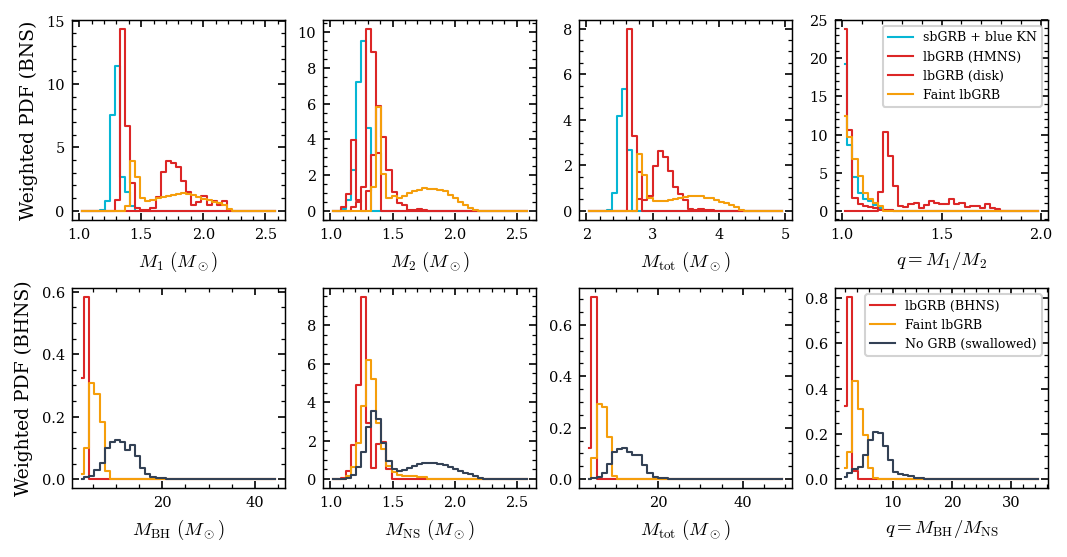

In [8]:
def _weighted_hist_pdf(data, mask, w, bins):
    if not mask.any():
        return None
    sub_d, sub_w = data[mask], w[mask]
    mu, _ = np.histogram(sub_d, bins=bins, weights=sub_w)
    binw = np.diff(bins)
    norm = sub_w.sum() * binw
    return 0.5 * (bins[:-1] + bins[1:]), mu / norm

bns_classes = [
    ('sbGRB + blue KN', sbGRB_blue,    C_SB_BLUE),
    ('lbGRB (HMNS)',    lbGRB_hmns,    C_LB_HMNS),
    ('lbGRB (disk)',    lbGRB_disk,    C_LB_DISK),
    ('Faint lbGRB',     bns_faint_lb,  C_FAINT),
]
bhns_classes = [
    ('lbGRB (BHNS)',       bhns_long,     C_LONG_BH),
    ('Faint lbGRB',        bhns_faint_lb, C_FAINT_BH),
    ('No GRB (swallowed)', bhns_no_grb,   C_NO_GRB),
]

bins_m  = np.linspace(1.0, 2.6, 40)
bins_mt = np.linspace(2.0, 5.0, 40)
bins_q  = np.linspace(1.0, 2.0, 40)
bins_bh = np.linspace(2, 45, 40)

fig, axes = plt.subplots(2, 4, figsize=(7.0, 3.6), constrained_layout=True)

bns_panels = [
    (m1_bns, bins_m,  r'$M_1\ (M_\odot)$'),
    (m2_bns, bins_m,  r'$M_2\ (M_\odot)$'),
    (M_tot,  bins_mt, r'$M_\mathrm{tot}\ (M_\odot)$'),
    (q_bns,  bins_q,  r'$q = M_1/M_2$'),
]
for ax, (data, bins, xlabel) in zip(axes[0], bns_panels):
    for lbl, mask, c in bns_classes:
        h = _weighted_hist_pdf(data, mask, w_bns, bins)
        if h is None:
            continue
        x, mu = h
        ax.step(x, mu, where='mid', color=c, lw=1.0, label=lbl)
    ax.set_xlabel(xlabel)
axes[0, 0].set_ylabel('Weighted PDF (BNS)')
axes[0, 3].legend(fontsize=6, loc='upper right', framealpha=0.85)

bhns_panels = [
    (BH,         bins_bh,                 r'$M_\mathrm{BH}\ (M_\odot)$'),
    (NS_bh,      bins_m,                  r'$M_\mathrm{NS}\ (M_\odot)$'),
    (BH + NS_bh, np.linspace(3, 50, 40),  r'$M_\mathrm{tot}\ (M_\odot)$'),
    (BH / NS_bh, np.linspace(1.5, 35, 40), r'$q = M_\mathrm{BH}/M_\mathrm{NS}$'),
]
for ax, (data, bins, xlabel) in zip(axes[1], bhns_panels):
    for lbl, mask, c in bhns_classes:
        h = _weighted_hist_pdf(data, mask, w_bhns, bins)
        if h is None:
            continue
        x, mu = h
        ax.step(x, mu, where='mid', color=c, lw=1.0, label=lbl)
    ax.set_xlabel(xlabel)
axes[1, 0].set_ylabel('Weighted PDF (BHNS)')
axes[1, 3].legend(fontsize=6, loc='upper right', framealpha=0.85)

fig.savefig('Plots/mass_distributions_by_class.png', dpi=300)
fig.savefig('Plots/mass_distributions_by_class.pdf')
plt.show()


## 3. Delay Time Distributions by GRB Class

Weighted PDFs of $t_\mathrm{delay} = t_\mathrm{form} + t_c$ per Gottlieb (2024) class. Sample is COMPAS Model A (BNS Zenodo 5189849, BHNS Zenodo 5178777).

- Each PDF is normalised within class: shape only, not relative fractions (rates in Section 7).
- BNS panel: HMNS solid, disk dashed (both lbGRB sub-classes share the palette red).
- Bins with $\sigma \geq \mu$ (single-system or empty) are dropped from the band so the log axis stays bounded.

In [ ]:
# Lower bin start to 3 Myr so the rising edge of the population (t ~ 5 Myr for
# CE-driven binaries) is shown rather than clipped at the bin wall.  Coarser
# 30 bins kill the single-system spikes that dominated the rare-class panels.
bins_delay = np.logspace(np.log10(3.0), np.log10(14000), 30)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 3.2),
                               constrained_layout=True)

# Linestyle distinguishes lbGRB (HMNS) from lbGRB (disk): both share the
# project-palette red (C_LB_HMNS == C_LB_DISK == '#DC2626'), so
# they overplot if drawn solid in the same panel.
bns_classes_dly = [
    ('sbGRB + blue KN',  sbGRB_blue,    C_SB_BLUE,  '-'),
    ('lbGRB (HMNS)',     lbGRB_hmns,    C_LB_HMNS,  '-'),
    ('lbGRB (disk)',     lbGRB_disk,    C_LB_DISK,  '--'),
    ('Faint lbGRB',      bns_faint_lb,  C_FAINT,    '-'),
]
bhns_classes_dly = [
    ('lbGRB (BHNS)',        bhns_long,     C_LONG_BH,   '-'),
    ('Faint lbGRB',         bhns_faint_lb, C_FAINT_BH,  '-'),
    ('No GRB (swallowed)',  bhns_no_grb,   C_NO_GRB,    '-'),
]

def _draw_dly(ax, data, mask, w, bins, color, label, ls):
    h = _weighted_hist_pdf(data, mask, w, bins)
    if h is None:
        return
    x, mu = h
    # Log y-axis: NaN-mask empty bins so step() does not drop a vertical edge
    # to zero between populated bins.
    mu_plot = np.where(mu > 0, mu, np.nan)
    ax.step(x, mu_plot, where='mid', color=color, lw=1.1, ls=ls, label=label)

for lbl, mask, c, ls in bns_classes_dly:
    _draw_dly(ax1, delay_bns, mask, w_bns, bins_delay, c, lbl, ls)
for lbl, mask, c, ls in bhns_classes_dly:
    _draw_dly(ax2, delay_bhns, mask, w_bhns, bins_delay, c, lbl, ls)

# BNS Faint lbGRB and sbGRB peaks reach ~1.5e-2 near t ~ 30 Myr; BHNS peaks
# are an order of magnitude lower, so per-panel ylim with separate ceilings.
for ax, ylab, ymax in ((ax1, 'Weighted PDF (BNS)',  5e-2),
                       (ax2, 'Weighted PDF (BHNS)', 5e-3)):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e1, bins_delay[-1])
    ax.set_ylim(1e-7, ymax)
    ax.set_xlabel(r'$t_\mathrm{delay}\ (\mathrm{Myr})$')
    ax.set_ylabel(ylab)
    ax.legend(fontsize=7, loc='lower left', framealpha=0.85)

fig.savefig('Plots/delay_time_distributions.png', dpi=300)
fig.savefig('Plots/delay_time_distributions.pdf')
plt.show()


## 4. Cosmic Integration: MSSFR Grid Setup

Setup for Sections 5, 7, 8, 12. Fiducial MSSFR is Levina et al. (2026, [arXiv:2601.20202](https://arxiv.org/abs/2601.20202)) Table 1 TNG100-1: Madau and Dickinson (2014) $S(z)$ with $a=0.0172, b=1.4425, c=4.5299, d=6.2261$ convolved with an Azzalini skew-log-normal $dP/d\ln Z$ ($\mu_0=0.0247, \mu_z=-0.0521, \omega_0=1.1509, \omega_z=0.0477, \alpha=-1.8801$). Integration via `compas_python_utils.cosmic_integration.FastCosmicIntegration`; `grb_rates.compute_merger_rate` chunks the FCI loop.

**CE prescription.** Webbink (1984) $\alpha$-formalism with $\alpha_\mathrm{CE}=1.0$ (Model A; F=0.5, G=2.0 in Section 12.1), Xu and Li (2010) $\lambda_\mathrm{CE}$, Hurley et al. (2002) $\zeta_\mathrm{ad}$. Pinned in `grb_rates.CE_PRESCRIPTION_BROEKGAARDEN21` (verified by `tests/anchors/test_literature_anchors.py::test_alpha_CE_per_model_matches_broekgaarden21_sec_5_2`).

$M_\mathrm{evolved}$ is back-derived from the COMPAS `weights_intrinsic/w_000` anchor (sampler-mass calibration only; MSSFR-independent). `dPdlogZ` is per $d(\ln Z)$, not $d(\log_{10} Z)$ (`check_dPdlogZ_normalization`).

In [ ]:
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), 'COMPAS'))
from compas_python_utils.cosmic_integration.FastCosmicIntegration import (
    calculate_redshift_related_params, find_sfr, find_metallicity_distribution)
from grb_rates import (SFR_PARAMS_LEVINA26_TNG100, MSSFR_PARAMS_LEVINA26_TNG100)

# Planck 2015 (H0 = 67.74, Om = 0.3089, OmL = 0.6911) to
# match COMPAS FastCosmicIntegration TNG-consistent values.  COMPAS
# cosmology.py defaults to Planck18, so we pass Planck15 explicitly to every
# call; otherwise distances and shell volumes drift by ~2 percent at high z.
from astropy.cosmology import Planck15 as PLANCK15
assert abs(PLANCK15.H0.value - 67.74) < 0.01

redshifts, n_z_detect, times, time_first_SF, distances, shell_volumes = \
    calculate_redshift_related_params(max_redshift=10.0, redshift_step=0.01,
                                       cosmology=PLANCK15)

# Fiducial MSSFR / SFR: Levina+ 2026 (arXiv:2601.20202) Table 1 best fit to
# IllustrisTNG TNG100-1.  Madau and Dickinson (2014) S(z) form, Azzalini
# skew-log-normal dP/dlnZ, alpha = -1.88 gives a long low-Z tail.
sfr = find_sfr(redshifts, **SFR_PARAMS_LEVINA26_TNG100)

Z_range_bns = verify_shared_metallicity_prior(DEFAULT_BNS_PATH, DEFAULT_BHNS_PATH)
dPdlogZ, metallicities, p_draw = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=np.log(Z_range_bns[0]),
    max_logZ_COMPAS=np.log(Z_range_bns[1]),
    **MSSFR_PARAMS_LEVINA26_TNG100)

try:
    dPdlogZ_norm = check_dPdlogZ_normalization(dPdlogZ, metallicities, rtol=0.10)
except ValueError:
    dlogZ = np.diff(np.log(metallicities))
    dlogZ = np.append(dlogZ, dlogZ[-1])
    dPdlogZ = dPdlogZ / (dPdlogZ * dlogZ[None, :]).sum(axis=1)[:, None]
    dPdlogZ_norm = (dPdlogZ * dlogZ[None, :]).sum(axis=1)

# Per-population MEAN_MASS_EVOLVED back-derived from upstream w_000 anchor.
# w_000 was pre-computed by the Broekgaarden+ 2021 cosmic integration with
# Neijssel+ 2019 MSSFR; calibrate_mean_mass_evolved re-runs that calculation
# internally and divides by expected_local_rate to recover the simulation's
# true total stellar mass evolved (a sampler property, MSSFR-independent),
# which we then feed into the Levina TNG100-1 forward pass below.
expected_rate_bns  = read_expected_local_rate(DEFAULT_BNS_PATH)
expected_rate_bhns = read_expected_local_rate(DEFAULT_BHNS_PATH)

mean_mass_bns = calibrate_mean_mass_evolved(
    redshifts, times, time_first_SF,
    Z_bns, delay_bns, w_bns, expected_rate_bns,
    Z_min_COMPAS=Z_range_bns[0], Z_max_COMPAS=Z_range_bns[1])
mean_mass_bhns = calibrate_mean_mass_evolved(
    redshifts, times, time_first_SF,
    Z_bhns, delay_bhns, w_bhns, expected_rate_bhns,
    Z_min_COMPAS=Z_range_bns[0], Z_max_COMPAS=Z_range_bns[1])
n_formed_BNS  = sfr / mean_mass_bns
n_formed_BHNS = sfr / mean_mass_bhns

print(f"SFR(z=0)            = {sfr[0]:.3e} Msun/yr/Gpc^3 (Levina+26 TNG100-1)")
print(f"dPdlogZ integral    in [{dPdlogZ_norm.min():.3f}, {dPdlogZ_norm.max():.3f}]")
print(f"p_draw              = {p_draw:.6f}")
print(f"BNS  R_loc anchor   = {expected_rate_bns:6.1f} Gpc^-3 yr^-1 (Neijssel w_000), "
      f"M_evolved = {mean_mass_bns:.3e} Msun")
print(f"BHNS R_loc anchor   = {expected_rate_bhns:6.1f} Gpc^-3 yr^-1 (Neijssel w_000), "
      f"M_evolved = {mean_mass_bhns:.3e} Msun")


## 4b. TNG-Resolution Sweep: TNG50-1 / TNG100-1 / TNG300-1

Robustness check on the MSSFR fiducial. Levina et al. (2026, arXiv:2601.20202, Sec. 3.2) report a factor 2 to 3 resolution effect on the local BBH rate (Table 2, analytical fit):

- TNG50-1: $\mathcal{R}_\mathrm{BBH}(z=0) = 73.7\ \mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$
- TNG100-1: $45.5$ (fiducial throughout the notebook)
- TNG300-1: $27.8$

`compute_merger_rate` is run once per variant via `LEVINA26_TNG_VARIANTS`; the TNG50 to TNG300 spread brackets the simulation-resolution systematic on the BNS rate.

In [ ]:
from grb_rates import LEVINA26_TNG_VARIANTS, LEVINA26_BBH_LOCAL_RATES
from scipy.ndimage import gaussian_filter1d

# Per-variant cosmic integration on the BNS A sample.  Reuses the existing
# (redshifts, times, time_first_SF, mean_mass_bns, Z_bns/delay_bns/w_bns)
# globals from Section 4 so the sweep is apples-to-apples (same cosmology,
# same Z-grid prior, same Alsing-remapped masses, only the Levina
# parameters differ).
#
# Two arrays kept per variant:
#   _R_bns_per_tng_raw[name] : unsmoothed compute_merger_rate output (the
#       physical R(z); used for the calibration-aware R(z=0) column).
#   _R_bns_per_tng[name]     : cosmetically smoothed copy used in the plot
#       (sigma=30 redshift bins; smoothes the discrete-Z-grid jaggedness).
# Splitting the two avoids the gaussian_filter1d reflective-boundary
# inflation of R(z=0) by ~factor 2 from contaminating the printed rates;
# the calibration-anchor invariant in grb_rates.calibrate_mean_mass_evolved
# uses smooth_sigma=0 for the same reason (CLAUDE.md "Calibration uses the
# unsmoothed convolution").
_R_bns_per_tng_raw = {}
_R_bns_per_tng = {}
for _name, (_sfr_p, _mssfr_p) in LEVINA26_TNG_VARIANTS.items():
    _sfr_v = find_sfr(redshifts, **_sfr_p)
    _dPdlogZ_v, _mets_v, _p_draw_v = find_metallicity_distribution(
        redshifts,
        min_logZ_COMPAS=np.log(Z_range_bns[0]),
        max_logZ_COMPAS=np.log(Z_range_bns[1]),
        **_mssfr_p,
    )
    _R_raw = compute_merger_rate(
        redshifts, times, time_first_SF, _sfr_v / mean_mass_bns, _p_draw_v,
        _dPdlogZ_v, _mets_v,
        Z_bns, delay_bns, w_bns,
        smooth_sigma=0,
    )
    _R_bns_per_tng_raw[_name] = _R_raw
    _R_bns_per_tng[_name] = gaussian_filter1d(_R_raw, sigma=30)

# Cividis triplet (perceptually uniform and colorblind-safe; the
# alternatives are viridis or batlow).  Section 12 reuses the same sampling indices
# (0.15, 0.50, 0.85) for its alpha_CE / NS_max sweep.
_cividis_tng = plt.get_cmap("cividis")(np.array([0.15, 0.50, 0.85]))
_tng_colours = {
    "TNG50-1":  tuple(_cividis_tng[0]),
    "TNG100-1": tuple(_cividis_tng[1]),
    "TNG300-1": tuple(_cividis_tng[2]),
}
_tng_styles = {
    "TNG50-1":  ("-",  1.2),
    "TNG100-1": ("-",  1.4),
    "TNG300-1": ("-",  1.2),
}

fig, ax = plt.subplots(figsize=(7.0, 3.0), constrained_layout=True)
ax.fill_between(
    redshifts,
    np.minimum(_R_bns_per_tng["TNG50-1"], _R_bns_per_tng["TNG300-1"]),
    np.maximum(_R_bns_per_tng["TNG50-1"], _R_bns_per_tng["TNG300-1"]),
    color=_tng_colours["TNG100-1"], alpha=0.18, lw=0,
    label="TNG-resolution envelope",
)
for _name in ("TNG300-1", "TNG100-1", "TNG50-1"):
    _ls, _lw = _tng_styles[_name]
    ax.plot(redshifts, _R_bns_per_tng[_name],
            color=_tng_colours[_name], ls=_ls, lw=_lw, label=_name)
ax.set_xlim(0, 10)
ax.set_yscale("log")
ax.set_ylim(bottom=0.1)
ax.set_xlabel(r"Redshift $z$")
ax.set_ylabel(r"$\mathcal{R}_\mathrm{BNS}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$")
ax.legend(fontsize=7, loc="upper right", ncol=2, framealpha=0.92)

# R(z=0) sanity table.  R(z=0,raw) is the physical unsmoothed value (the
# right number to compare against any external reference or anchor);
# R(z=0,sm) is the cosmetically smoothed value that the plot shows, and
# sits ~2x higher because gaussian_filter1d's reflective boundary at z=0
# folds in the rising side of R(z).  Both columns preserve the Levina
# Table 2 BBH ordering (TNG50 > TNG100 > TNG300).
iz0 = int(np.argmin(np.abs(redshifts)))
print(f"{'TNG':10s} {'R_BNS(z=0,raw)':>16s} {'R_BNS(z=0,sm)':>16s}   {'Levina BBH R_fit':>18s}")
for _name in _R_bns_per_tng_raw:
    _R0_raw = float(_R_bns_per_tng_raw[_name][iz0])
    _R0_sm  = float(_R_bns_per_tng[_name][iz0])
    _R_bbh_fit = LEVINA26_BBH_LOCAL_RATES[_name]["R_fit"]
    print(f"  {_name:8s}  {_R0_raw:14.3f}   {_R0_sm:14.3f}        {_R_bbh_fit:6.2f}")

fig.savefig("Plots/rate_bns_tng_sweep.png", dpi=300)
fig.savefig("Plots/rate_bns_tng_sweep.pdf")
plt.show()

## 5. Metallicity Dependence of GRB Formation Efficiency

Formation efficiency $\eta(Z)$ (mergers per $M_\odot$ formed) per Gottlieb (2024) class. Lower $Z$ produces heavier remnants and tilts the class balance, propagating to $z$ via the MSSFR convolution. $Z_\odot = 0.0142$ (Asplund et al. 2009); bins with fewer than $N_\mathrm{min}$ simulated systems are faded.

In [ ]:
eff_bns = formation_efficiency(
    METALLICITY_GRID, Z_bns, w_bns,
    masks={'sbGRB + blue KN': sbGRB_blue,
           'lbGRB (HMNS)':    lbGRB_hmns,
           'lbGRB (disk)':    lbGRB_disk,
           'Faint lbGRB':     bns_faint_lb},
    mean_mass_evolved=mean_mass_bns)
eff_bhns = formation_efficiency(
    METALLICITY_GRID, Z_bhns, w_bhns,
    masks={'Long cbGRB (BHNS)':     bhns_long,
           'Short cbGRB (BHNS)':    bhns_faint_lb,
           'No GRB (NS swallowed)': bhns_no_grb},
    mean_mass_evolved=mean_mass_bhns)

# Drop the duplicated final 0.03 entry in METALLICITY_GRID.
Z_SUN = 0.0142
_uniq_mask = np.concatenate(([True], np.diff(METALLICITY_GRID) != 0))
Z_grid = METALLICITY_GRID[_uniq_mask]
Z_over_Zsun = Z_grid / Z_SUN

# Vectorized per-bin sample counts via searchsorted + bincount; no Python
# loop over the metallicity grid.
def _bin_counts(Z_systems, grid):
    idx = np.clip(np.searchsorted(grid, Z_systems), 0, len(grid) - 1)
    return np.bincount(idx, minlength=len(grid))

N_bns  = _bin_counts(Z_bns,  Z_grid)
N_bhns = _bin_counts(Z_bhns, Z_grid)
N_MIN  = 50
ok_bns_bin  = N_bns  >= N_MIN
ok_bhns_bin = N_bhns >= N_MIN

print(f'BNS  : {ok_bns_bin.sum():>2d}/{len(Z_grid)} bins well-sampled '
      f'(N >= {N_MIN}); coverage Z/Zsun '
      f'[{Z_over_Zsun[ok_bns_bin].min():.3f}, '
      f'{Z_over_Zsun[ok_bns_bin].max():.3f}]')
print(f'BHNS : {ok_bhns_bin.sum():>2d}/{len(Z_grid)} bins well-sampled')

def _split(arr, ok_bin):
    a = arr[_uniq_mask].astype(float)
    a[a <= 0] = np.nan
    return (np.where(ok_bin, a, np.nan),
            np.where(~ok_bin & np.isfinite(a), a, np.nan))

fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.6), sharex=True,
                         constrained_layout=True)

def _draw_efficiency(ax, eff, classes, ok_bin, total_label):
    for lbl, c in classes:
        well, under = _split(eff[lbl], ok_bin)
        ax.plot(Z_over_Zsun, well,  color=c, lw=1.1, marker='o', ms=2.5,
                label=lbl)
        ax.plot(Z_over_Zsun, under, color=c, lw=0, marker='o', mfc='none',
                ms=3, alpha=0.4)
    well_t, under_t = _split(eff['total'], ok_bin)
    ax.plot(Z_over_Zsun, well_t,  color=C_TEXT, lw=1.4, marker='o', ms=2.5,
            label=total_label)
    ax.plot(Z_over_Zsun, under_t, color=C_TEXT, lw=0, marker='o', mfc='none',
            ms=3, alpha=0.4)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.axvline(1.0, color=C_GUIDE, lw=0.8, ls=':', zorder=0)
    ax.set_ylabel(r'$\eta(Z)\ (\mathrm{mergers}/M_\odot)$')

_draw_efficiency(axes[0, 0], eff_bns,
                 [('sbGRB + blue KN', C_SB_BLUE),
                  ('lbGRB (HMNS)',    C_LB_HMNS),
                  ('lbGRB (disk)',    C_LB_DISK),
                  ('Faint lbGRB',     C_FAINT)],
                 ok_bns_bin, 'Total BNS')
axes[0, 0].legend(fontsize=6, loc='lower left', framealpha=0.9)

_draw_efficiency(axes[0, 1], eff_bhns,
                 [('Long cbGRB (BHNS)',     C_LONG_BH),
                  ('Short cbGRB (BHNS)',    C_FAINT_BH),
                  ('No GRB (NS swallowed)', C_NO_GRB)],
                 ok_bhns_bin, 'Total BHNS')
axes[0, 1].legend(fontsize=6, loc='lower left', framealpha=0.9)

# Lock y-range to well-sampled bins so a single under-sampled outlier
# doesn't drag the floor down.
def _well_sampled_range(eff, ok_bin):
    vals = []
    for v in eff.values():
        a = v[_uniq_mask][ok_bin]
        a = a[a > 0]
        if a.size:
            vals.append(a)
    return (np.concatenate(vals).min(), np.concatenate(vals).max()) if vals else None

ranges = [r for r in (_well_sampled_range(eff_bns,  ok_bns_bin),
                      _well_sampled_range(eff_bhns, ok_bhns_bin)) if r]
if ranges:
    axes[0, 0].set_ylim(min(r[0] for r in ranges) / 3.0,
                        max(r[1] for r in ranges) * 3.0)
    axes[0, 1].set_ylim(*axes[0, 0].get_ylim())

# Fraction stackplots.
def _stack(ax, eff, ok_bin, keys, colors, labels, ylabel):
    denom = eff['total'][_uniq_mask]
    sel   = ok_bin & (denom > 0)
    with np.errstate(invalid='ignore', divide='ignore'):
        fracs = np.stack([eff[k][_uniq_mask] / denom for k in keys])
    ax.stackplot(Z_over_Zsun[sel], *fracs[:, sel],
                 colors=colors, labels=labels, alpha=0.85)
    ax.set_xscale('log')
    ax.set_xlabel(r'$Z\,/\,Z_\odot$')
    ax.set_ylabel(ylabel)
    ax.axvline(1.0, color='white', lw=1.0, ls=':', alpha=0.9, zorder=5)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=6, loc='upper left', framealpha=0.9)

_stack(axes[1, 0], eff_bns, ok_bns_bin,
       ['sbGRB + blue KN', 'lbGRB (HMNS)', 'lbGRB (disk)', 'Faint lbGRB'],
       [C_SB_BLUE, C_LB_HMNS, C_LB_DISK, C_FAINT],
       ['sbGRB + blue KN', 'lbGRB (HMNS)', 'lbGRB (disk)', 'Faint lbGRB'],
       'Fraction (BNS)')
_stack(axes[1, 1], eff_bhns, ok_bhns_bin,
       ['Long cbGRB (BHNS)', 'Short cbGRB (BHNS)', 'No GRB (NS swallowed)'],
       [C_LONG_BH, C_FAINT_BH, C_NO_GRB],
       ['Long cbGRB', 'Short cbGRB', 'No GRB'],
       'Fraction (BHNS)')

# Lock x-range to well-sampled coverage.
xs = [Z_over_Zsun[ok] for ok in (ok_bns_bin, ok_bhns_bin) if ok.any()]
if xs:
    cat = np.concatenate(xs)
    for a in axes.flat:
        a.set_xlim(cat.min() / 1.5, cat.max() * 1.5)

fig.savefig('Plots/metallicity_dependence.png', dpi=300)
fig.savefig('Plots/metallicity_dependence.pdf')
plt.show()


## 6. BNS Merger Rate $\mathcal{R}(z)$ per Formation Channel

Intrinsic $\mathcal{R}(z)$ (Gpc$^{-3}$ yr$^{-1}$) split onto the five Broekgaarden et al. (2021, 2022) channels (I Stable MT + CE, II Stable MT only, III Single-core CE, IV Double-core CE, V Other) under Levina et al. (2026) TNG100-1 MSSFR and Planck 2015. Rates are intrinsic upper bounds (100 percent jet launching above threshold).

The additivity tripwire $\sum_c \mathcal{R}_c \approx \mathcal{R}_\mathrm{All\,BNS}$ holds at `rtol=1e-12` because V is the exhaustive catch-all in `classify_formation_channels`. Case-A donors fold into I or II per Broekgaarden+ 2022 Sec. 3.2.

In [ ]:
channels = classify_formation_channels(
    dblCE=bns_ch['dblCE'], fc_CEE=bns_ch['fc_CEE'],
    fc_mt_p1=bns_ch['fc_mt_p1'], fc_mt_s1=bns_ch['fc_mt_s1'],
    fc_mt_p1_K1=bns_ch['fc_mt_p1_K1'], fc_mt_s1_K2=bns_ch['fc_mt_s1_K2'])

# channels keys are already in Broekgaarden order I, II, III, IV, V from
# classify_formation_channels.  Keep the full keys (with descriptive suffix)
# so every label in the legend, summary print, and saved PNG carries both
# the roman numeral and the channel name.
def _pretty_ch(key):
    parts = key.split(None, 1)
    return f"{parts[0]} ({parts[1]})" if len(parts) == 2 else key

chan_items = list(channels.items())
chan_items.append(('All BNS', np.ones(len(delay_bns), dtype=bool)))

# Match the Section 6 bar chart palette per channel.
ch_colors = {
    'I  Stable MT + CE':  '#3B82F6',
    'II  Stable MT only': '#10B981',
    'III Single-core CE': '#F59E0B',
    'IV  Double-core CE': '#EF4444',
    'V   Other':          '#8B5CF6',
    'All BNS':            C_TEXT,
}

merger_rates_ch = {}
for label, mask in chan_items:
    merger_rates_ch[label] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, p_draw,
        dPdlogZ, metallicities,
        Z_bns[mask], delay_bns[mask], w_bns[mask])

# Additivity tripwire (matches the Section 7 R_sum_2024 idiom): the five
# Broekgaarden channels exhaustively partition the merging BNS sample because
# classify_formation_channels closes the I-V partition with a final
# ch_other = ~(ch_I | ch_II | ch_III | ch_IV) sweep, so the channel rates
# must sum to the All-BNS curve at machine precision.  Do NOT recalibrate
# MEAN_MASS_EVOLVED per channel; n_formed_BNS is a population-level constant
# and per-channel rates are fractions of that calibrated total.
R_sum_ch = sum(merger_rates_ch[lbl] for lbl, _ in chan_items[:-1])
assert np.allclose(R_sum_ch, merger_rates_ch['All BNS'], rtol=1e-12, atol=0), \
    "Channel partition is no longer additive on production data"

iz0 = int(np.argmin(np.abs(redshifts)))
print('Channel                       R(z=0) [Gpc^-3 yr^-1]')
for label, _ in chan_items:
    print(f"  {_pretty_ch(label):26s}  "
          f"{rate_label(merger_rates_ch[label][iz0]):>8s}")

fig, ax = plt.subplots(figsize=(7.0, 3.0), constrained_layout=True)
for label, _ in chan_items:
    R = merger_rates_ch[label]
    lw = 1.6 if label == 'All BNS' else 1.1
    ax.plot(redshifts, R, color=ch_colors[label], lw=lw,
            label=_pretty_ch(label))
ax.set_xlim(0, 10)
ax.set_yscale('log')
ax.set_ylim(bottom=0.1)
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax.legend(fontsize=6, loc='upper right', ncol=2,
          title='Formation channel', title_fontsize=7)
fig.savefig('Plots/rate_bns_by_channel.pdf')
fig.savefig('Plots/rate_bns_by_channel.png', dpi=300)
plt.show()


## 7. BNS Merger Rate $\mathcal{R}(z)$ per GRB Class

Intrinsic $\mathcal{R}(z)$ (Gpc$^{-3}$ yr$^{-1}$) per Gottlieb (2024) class under Levina et al. (2026) TNG100-1 MSSFR ($\alpha = -1.88$) and Planck 2015. Upper bounds (100 percent jet launching). HMNS solid, disk dashed (palette red shared). Additivity holds at `rtol=1e-12`. $M_\mathrm{evolved}$ is back-derived from the Broekgaarden et al. (2021) `weights_intrinsic/w_000` anchor (sampler-mass calibration only; science-path MSSFR is Levina TNG100-1).

**Detected vs intrinsic (panel below).** Section 7 curves folded through `compas_python_utils.cosmic_integration.FastCosmicIntegration.find_detection_probability` ($\rho \geq 8$, Finn and Chernoff 1993 antenna pattern) via `grb_rates.detected_rate` give the LIGO O3 detection-rate density. Defined up to the FCI default horizon $z_\mathrm{det} = 1$; beyond that BNS chirp masses fall below the O3 noise curve. This is the GW complement to the Section 10 beaming correction. Pass `sensitivity='design'` for 3G or `'O1'` for early-LIGO.

In [ ]:
classes_BNS_24 = [
    ('sbGRB + blue KN', sbGRB_blue),
    ('lbGRB (HMNS)',    lbGRB_hmns),
    ('lbGRB (disk)',    lbGRB_disk),
    ('Faint lbGRB',     bns_faint_lb),
    ('All BNS',         np.ones(len(delay_bns), dtype=bool)),
]

merger_rates_BNS = {}
for label, mask in classes_BNS_24:
    merger_rates_BNS[label] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, p_draw,
        dPdlogZ, metallicities,
        Z_bns[mask], delay_bns[mask], w_bns[mask])

iz0 = np.argmin(np.abs(redshifts))
for label in [c[0] for c in classes_BNS_24]:
    print(f"  {label:18s}  R(z=0) = {rate_label(merger_rates_BNS[label][iz0]):>8s} Gpc^-3 yr^-1")

# Production-side additivity tripwire: the four 2024 classes partition the
# BNS sample (test_per_class_rates_partition_total_bns_2024 covers the
# unit-level invariant; this asserts it on the actual production data so
# a future regression in compute_merger_rate or classify_bns_2024 fails
# the cell rather than silently distorting the figure).
R_sum_2024 = sum(merger_rates_BNS[lbl] for lbl, _ in classes_BNS_24[:-1])
assert np.allclose(R_sum_2024, merger_rates_BNS['All BNS'],
                   rtol=1e-12, atol=0), \
    "BNS class partition is no longer additive on production data"

fig, ax = plt.subplots(figsize=(7.0, 3.0), constrained_layout=True)
# Linestyle distinguishes lbGRB (HMNS) from lbGRB (disk): both share the
# project-palette red (C_LB_HMNS == C_LB_DISK == '#DC2626'), so
# HMNS is solid and disk is dashed, matching the Section 6 delay-time panel.
style = [('sbGRB + blue KN', C_SB_BLUE,  '-',  1.1),
         ('lbGRB (HMNS)',    C_LB_HMNS,  '-',  1.1),
         ('lbGRB (disk)',    C_LB_DISK,  '--', 1.1),
         ('Faint lbGRB',     C_FAINT,    '-',  1.0),
         ('All BNS',         C_TEXT,     '-',  1.6)]
for lbl, c, ls, lw in style:
    R = merger_rates_BNS[lbl]
    ax.plot(redshifts, R, color=c, ls=ls, lw=lw, label=lbl)
ax.set_xlim(0, 10)
ax.set_yscale('log')
ax.set_ylim(bottom=0.1)
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax.legend(fontsize=6, loc='upper right', ncol=2)
fig.savefig('Plots/rate_bns_by_class.png', dpi=300)
fig.savefig('Plots/rate_bns_by_class.pdf')
plt.show()


In [ ]:
from grb_rates import detected_rate

# n_z_detect comes from Section 4's calculate_redshift_related_params
# (FCI default max_redshift_detection = 1.0).  redshifts[:n_z_detect] is
# the source-frame slice up to which BNS detection probabilities are
# meaningful given the O3 noise curve.
_z_det = redshifts[:n_z_detect]

R_bns_det_O3 = {}
for label, mask in classes_BNS_24:
    R_bns_det_O3[label] = detected_rate(
        redshifts, times, time_first_SF, n_formed_BNS, p_draw,
        dPdlogZ, metallicities,
        m1_bns[mask], m2_bns[mask], Z_bns[mask], delay_bns[mask], w_bns[mask],
        distances, n_z_detect,
        sensitivity='O3', snr_threshold=8.0,
    )

iz0 = int(np.argmin(np.abs(redshifts)))
print(f"  {'Class':25s}  {'R_int(z=0)':>12s}  {'R_det^O3(z=0)':>15s}  {'detected/intrinsic':>22s}")
for label, _ in classes_BNS_24:
    R_int_0 = float(merger_rates_BNS[label][iz0])
    R_det_0 = float(R_bns_det_O3[label][0])
    frac = R_det_0 / R_int_0 if R_int_0 > 0 else float('nan')
    print(f"  {label:25s}  {rate_label(R_int_0):>12s}  {rate_label(R_det_0):>15s}  {frac * 100:>20.2f} %")

# Two-line panel: intrinsic per-class on top (z = 0 to 10) and the O3
# detected restriction on bottom (z = 0 to z_det).  Same colour palette as
# Section 7 so readers can map class identity across panels.
fig, (ax_int, ax_det) = plt.subplots(
    2, 1, figsize=(7.0, 5.0), constrained_layout=True,
    gridspec_kw=dict(height_ratios=[1.0, 1.0], hspace=0.10),
)
_style_7b = [
    ('sbGRB + blue KN', C_SB_BLUE, '-',  1.1),
    ('lbGRB (HMNS)',    C_LB_HMNS, '-',  1.1),
    ('lbGRB (disk)',    C_LB_DISK, '--', 1.1),
    ('Faint lbGRB',     C_FAINT,   '-',  1.0),
    ('All BNS',         C_TEXT,    '-',  1.6),
]
for lbl, c, ls, lw in _style_7b:
    ax_int.plot(redshifts, merger_rates_BNS[lbl], color=c, ls=ls, lw=lw, label=lbl)
    ax_det.plot(_z_det, R_bns_det_O3[lbl], color=c, ls=ls, lw=lw)

ax_int.set_xlim(0, 10)
ax_int.set_yscale('log')
ax_int.set_ylim(bottom=0.1)
ax_int.set_ylabel(r'$\mathcal{R}_\mathrm{int}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax_int.legend(fontsize=6, loc='upper right', ncol=2, framealpha=0.92)
ax_int.text(0.02, 0.94, 'Intrinsic', transform=ax_int.transAxes,
            fontsize=7, va='top', ha='left', color=C_TEXT,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=C_BOX_EDGE, alpha=0.85))

ax_det.set_xlim(0, float(_z_det.max()))
ax_det.set_yscale('log')
ax_det.set_ylim(bottom=1e-3)
ax_det.set_xlabel(r'Redshift $z$')
ax_det.set_ylabel(r'$\mathcal{R}_\mathrm{det}^{\mathrm{O3}}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax_det.text(0.02, 0.94, 'O3 detected ($\\rho \\geq 8$)',
            transform=ax_det.transAxes, fontsize=7, va='top', ha='left',
            color=C_TEXT,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=C_BOX_EDGE, alpha=0.85))

fig.savefig('Plots/rate_bns_detected_vs_intrinsic.png', dpi=300)
fig.savefig('Plots/rate_bns_detected_vs_intrinsic.pdf')
plt.show()

## 8. BHNS Merger Rate $\mathcal{R}(z)$ with BH Spin Sensitivity

BHNS $\mathcal{R}(z)$ is dominated by $a_\mathrm{BH}$: higher spins move the ISCO inward and lift the surviving NS fraction (Foucart 2018).

- Class colour: red lbGRB ($M_\mathrm{disk} \geq 0.1\,M_\odot$); orange Faint lbGRB ($0.01 \leq M_\mathrm{disk} < 0.1\,M_\odot$).
- Spin grid: $a_\mathrm{BH} \in \{0, 0.3, 0.5, 0.7, 0.9\}$ (`clip_chi=0.9` respects the Foucart calibration). Fiducial centre line $A_\mathrm{BH,fid} = 0.5$.
- Per-class curves carry the misalignment factor 0.5 (`apply_bhns_misalignment`, Fragos et al. 2010, Kawaguchi et al. 2015). The black All-BHNS trace is *intrinsic*: misalignment is a jet-orientation cut and does not apply to the $\sim 67\%$ of BHNS that swallow the NS.
- Gap between black and coloured envelopes = sub-threshold disks ($M_\mathrm{disk} < 0.01\,M_\odot$) + GRB-class systems lost to misalignment.
- Statistical Poisson uncertainty is sub-percent; the BH-spin envelope is the dominant systematic.

In [ ]:
spin_grid = [0.0, 0.3, 0.5, 0.7, 0.9]
spin_rates_long, spin_rates_short = {}, {}
# Misalignment is applied at the source (commutes with marginalize_bh_spin
# because the factor is a scalar 0.5), so r_long_fm19 / r_short_fm19 below
# inherit the correction and the Section 10 beaming comparison stays
# consistent.  The All-BHNS reference computed further down is the
# *intrinsic* merger rate (no misalignment): MISALIGNMENT_SYSTEMATIC_FACTOR
# is a jet-orientation reduction (see grb_physics.py docstring), and the
# ~67 percent of BHNS systems that swallow the NS launch no jet, so the
# 0.5x correction does not apply to them.
for a in spin_grid:
    cbh = classify_bhns(BH, NS_bh, a_BH=a, clip_chi=0.9)
    spin_rates_long[a]  = apply_bhns_misalignment(compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
        dPdlogZ, metallicities,
        Z_bhns[cbh['Long cbGRB']],  delay_bhns[cbh['Long cbGRB']],
        w_bhns[cbh['Long cbGRB']]))
    spin_rates_short[a] = apply_bhns_misalignment(compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
        dPdlogZ, metallicities,
        Z_bhns[cbh['Short cbGRB']], delay_bhns[cbh['Short cbGRB']],
        w_bhns[cbh['Short cbGRB']]))

iz0 = np.argmin(np.abs(redshifts))
for a in spin_grid:
    print(f"  a={a:.1f}  Long: {rate_label(spin_rates_long[a][iz0]):>6s}  "
          f"Short: {rate_label(spin_rates_short[a][iz0]):>6s} Gpc^-3 yr^-1")

# BH-spin marginalization (moved from the dropped Section 11). Flat prior is
# uniform over the spin grid; Fuller and Ma (2019, arXiv:1905.08793) predict
# efficient angular-momentum transport, so most BHs form with low spin.
w_flat = {0.0: 0.20, 0.3: 0.20, 0.5: 0.20, 0.7: 0.20, 0.9: 0.20}
w_fm19 = {0.0: 0.70, 0.3: 0.20, 0.5: 0.07, 0.7: 0.02, 0.9: 0.01}
r_long_flat  = marginalize_bh_spin(spin_rates_long,  w_flat)
r_long_fm19  = marginalize_bh_spin(spin_rates_long,  w_fm19)
r_short_flat = marginalize_bh_spin(spin_rates_short, w_flat)
r_short_fm19 = marginalize_bh_spin(spin_rates_short, w_fm19)

rate_bhns_all = compute_merger_rate(
    redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
    dPdlogZ, metallicities,
    Z_bhns, delay_bhns, w_bhns)

# Per-class shaded BH-spin envelope (CLAUDE.md "Scientific Plotting
# Standards" prescribes shaded bands for spin / EOS sweeps).  The band is
# min-to-max over the spin grid a in [0, 0.9]; the solid centre line is
# the fiducial A_BH_FID = 0.5.  The lbGRB lower edge collapses near zero
# at a=0 (Schwarzschild ISCO at 6GM/c^2; Bardeen, Press, Teukolsky 1972,
# ApJ 178, 347) because almost no NS material survives above
# MDISK_LONG = 0.1 Msun (Foucart 2018, Kruger and Foucart 2020), so the
# lower bound is floored at Y_FLOOR to keep the log axis bounded.  The
# All-BHNS reference is the *intrinsic* merger rate; the per-class bands
# include the 0.5x population-averaged jet-misalignment suppression, so
# the gap between black and the coloured bands is sub-threshold-disk
# mergers + would-be jet GRBs lost to misalignment.
Y_FLOOR = 1e-4
long_stack  = np.stack([spin_rates_long[a]  for a in spin_grid])
short_stack = np.stack([spin_rates_short[a] for a in spin_grid])
long_lo,  long_hi  = long_stack.min(axis=0),  long_stack.max(axis=0)
short_lo, short_hi = short_stack.min(axis=0), short_stack.max(axis=0)

fig, ax = plt.subplots(figsize=(7.0, 3.5), constrained_layout=True)

ax.fill_between(redshifts, np.maximum(long_lo, Y_FLOOR), long_hi,
                color=C_LB_DISK, alpha=0.20, lw=0,
                label=r'lbGRB envelope ($a \in [0, 0.9]$)')
ax.plot(redshifts, spin_rates_long[0.5],  color=C_LB_DISK, lw=1.8,
        label=r'lbGRB fiducial ($a=0.5$)')
ax.fill_between(redshifts, np.maximum(short_lo, Y_FLOOR), short_hi,
                color=C_FAINT,   alpha=0.30, lw=0,
                label=r'Faint lbGRB envelope ($a \in [0, 0.9]$)')
ax.plot(redshifts, spin_rates_short[0.5], color=C_FAINT,   lw=1.8,
        label=r'Faint lbGRB fiducial ($a=0.5$)')
ax.plot(redshifts, rate_bhns_all, color=C_TEXT, lw=1.8,
        label='All BHNS (intrinsic merger rate)')

ax.set_xlim(0, 10)
ax.set_yscale('log')
ax.set_ylim(Y_FLOOR, 1e3)
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')

# All BHNS first (reference total), then per class with fiducial above its
# envelope so the eye reads top-to-bottom: reference, then lbGRB, then Faint
# lbGRB.  ncol=1 is intentional; ncol=2 pairs adjacent entries visually and
# would put All BHNS next to a Faint lbGRB row.
handles, labels = ax.get_legend_handles_labels()
order = [4, 1, 0, 3, 2]
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          fontsize=7, loc='upper right', ncol=1, frameon=True,
          framealpha=0.92, edgecolor=C_BOX_EDGE,
          handlelength=1.8).set_zorder(10)

ax.text(
    0.02, 0.10,
    r'lbGRB at $a=0$: NS plunged (envelope floor)',
    transform=ax.transAxes, fontsize=7, color=C_TEXT,
    va='bottom', ha='left',
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=C_BOX_EDGE, alpha=0.85),
)

fig.savefig('Plots/rate_bhns_spin_sensitivity.png', dpi=300)
fig.savefig('Plots/rate_bhns_spin_sensitivity.pdf')
plt.show()


## 8b. BHNS Merger Rate $\mathcal{R}(z)$ per Formation Channel

BHNS $\mathcal{R}(z)$ split onto the five Broekgaarden et al. (2021, 2022) channels (convention as in Section 6) under the same Levina et al. (2026) TNG100-1 MSSFR + Planck 2015. Per-channel curves carry the misalignment factor 0.5 (`apply_bhns_misalignment`); the All-BHNS reference is intrinsic (matching Section 8 black). Additivity $\sum_c \mathcal{R}_c \approx 0.5 \times \mathcal{R}_\mathrm{All\,BHNS,intrinsic}$ at `rtol=1e-12` (scalar misalignment commutes with the channel split). Channel IV is essentially zero for BHNS (BH progenitor is too massive at CE onset for both stars to be in core-He burning). Channels are insensitive to $a_\mathrm{BH}$ and the EOS, so the figure does not repeat over those sweeps.

In [ ]:
# classify_formation_channels is population-agnostic: same event-history
# columns as BNS (Section 6).  IV (Double-core CE) is essentially empty for
# BHNS but is kept in the iteration to make the partition exhaustive so the
# additivity tripwire below stays meaningful.
channels_bhns = classify_formation_channels(
    dblCE=bhns_ch['dblCE'], fc_CEE=bhns_ch['fc_CEE'],
    fc_mt_p1=bhns_ch['fc_mt_p1'], fc_mt_s1=bhns_ch['fc_mt_s1'],
    fc_mt_p1_K1=bhns_ch['fc_mt_p1_K1'], fc_mt_s1_K2=bhns_ch['fc_mt_s1_K2'])

def _pretty_ch(key):
    parts = key.split(None, 1)
    return f"{parts[0]} ({parts[1]})" if len(parts) == 2 else key

chan_items = list(channels_bhns.items())
chan_items.append(('All BHNS', np.ones(n_bhns, dtype=bool)))

# Match the Section 6b channel palette so the same colour is the same
# channel across BNS and BHNS panels.
ch_colors = {
    'I  Stable MT + CE':  '#3B82F6',
    'II  Stable MT only': '#10B981',
    'III Single-core CE': '#F59E0B',
    'IV  Double-core CE': '#EF4444',
    'V   Other':          '#8B5CF6',
    'All BHNS':           C_TEXT,
}

# Misalignment is a uniform scalar (apply_bhns_misalignment * 0.5; CLAUDE.md
# population-averaged Fragos+ 2010 / Kawaguchi+ 2015), so it commutes with
# the channel split: applying it per channel preserves additivity.  The
# All-BHNS reference is the *intrinsic* merger rate (Section 8 convention:
# MISALIGNMENT_SYSTEMATIC_FACTOR is a jet-orientation reduction and the
# ~67 percent No-GRB systems launch no jet); the additivity tripwire below
# rescales it by 0.5 to compare against the GRB-suppressed per-channel sum.
merger_rates_ch_bhns = {}
for label, mask in chan_items:
    R = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, p_draw,
        dPdlogZ, metallicities,
        Z_bhns[mask], delay_bhns[mask], w_bhns[mask])
    if label == 'All BHNS':
        merger_rates_ch_bhns[label] = R
    else:
        merger_rates_ch_bhns[label] = apply_bhns_misalignment(R)

R_sum_ch = sum(merger_rates_ch_bhns[lbl] for lbl, _ in chan_items[:-1])
assert np.allclose(
    R_sum_ch,
    apply_bhns_misalignment(merger_rates_ch_bhns['All BHNS']),
    rtol=1e-12, atol=0,
), "BHNS channel partition is no longer additive on production data"

iz0 = int(np.argmin(np.abs(redshifts)))
print('Channel                       R(z=0) [Gpc^-3 yr^-1]')
for label, _ in chan_items:
    print(f"  {_pretty_ch(label):26s}  "
          f"{rate_label(merger_rates_ch_bhns[label][iz0]):>8s}")

fig, ax = plt.subplots(figsize=(7.0, 3.0), constrained_layout=True)
for label, _ in chan_items:
    R = merger_rates_ch_bhns[label]
    # All BHNS is a thin dotted overlay so Channel I (Stable MT plus CE,
    # ~99 percent of the BHNS total per Broekgaarden+ 2021 Sec. 5) stays
    # visible underneath rather than being covered by a heavier solid total.
    is_total = (label == 'All BHNS')
    ax.plot(redshifts, R, color=ch_colors[label],
            lw=1.0 if is_total else 1.1,
            ls=':' if is_total else '-',
            label=_pretty_ch(label))
ax.set_xlim(0, 10)
ax.set_yscale('log')
ax.set_ylim(bottom=1e-3)
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax.legend(fontsize=6, loc='upper right', ncol=2,
          title='Formation channel', title_fontsize=7)
fig.savefig('Plots/rate_bhns_by_channel.pdf')
fig.savefig('Plots/rate_bhns_by_channel.png', dpi=300)
plt.show()


## 9. Physical Host-Galaxy Offset Distributions

Orbit-integrated projected offsets in a Hernquist (1990) potential, replacing the unbound ballistic upper bound (Bloom et al. 1999, Fong and Berger 2013). Each binary's birth radius is drawn from the Hernquist stellar profile; kicks are isotropic. Hosts are a 75/25 mix of star-forming and elliptical (Fong and Berger 2013); the F&B sample is afterglow + host selected, so model CDFs extend to larger offsets than the observed sample.

In [ ]:
from grb_offsets import (compute_offsets_mixed_hosts,
                         weighted_offset_cdf,
                         OBSERVED_SGRB_OFFSETS_KPC,
                         OBSERVED_LGRB_MERGER_OFFSETS_KPC)
from scipy.stats import ks_2samp

bns_classes_off = [
    ('sbGRB + blue KN', sbGRB_blue,   C_SB_BLUE, '-'),
    ('lbGRB (HMNS)',    lbGRB_hmns,   C_LB_HMNS, '--'),
    ('lbGRB (disk)',    lbGRB_disk,   C_LB_DISK, '-.'),
    ('Faint lbGRB',     bns_faint_lb, C_FAINT,   ':'),
]
bhns_classes_off = [
    ('lbGRB (BHNS)',       bhns_long,     C_LONG_BH,  '-'),
    ('Faint lbGRB (BHNS)', bhns_faint_lb, C_FAINT_BH, '--'),
]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0), constrained_layout=True)

ax1 = axes[0]
bns_offset_results = {}
ks_results_bns = {}
for lbl, mask, c, ls in bns_classes_off:
    res = compute_offsets_mixed_hosts(
        v_sys_bns[mask], delay_bns[mask], weights=w_bns[mask], max_systems=20000)
    if len(res['mixed_offsets']) < 10:
        continue
    bns_offset_results[lbl] = (res['mixed_offsets'], res['mixed_weights'])
    x, cdf = weighted_offset_cdf(res['mixed_offsets'], res['mixed_weights'])
    ax1.plot(x, cdf, color=c, ls=ls, lw=1.2, label=lbl)
    finite = res['mixed_offsets'][np.isfinite(res['mixed_offsets'])]
    if len(finite) > 1:
        ks_results_bns[lbl] = ks_2samp(finite, OBSERVED_SGRB_OFFSETS_KPC)

obs_sorted = np.sort(OBSERVED_SGRB_OFFSETS_KPC)
obs_cdf    = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)
ax1.step(obs_sorted, obs_cdf, color=C_OBS, lw=1.2, ls='-', alpha=0.85,
         where='post', label='Obs. SGRB (F&B 2013)')
if 'lbGRB (HMNS)' in ks_results_bns:
    ks = ks_results_bns['lbGRB (HMNS)']
    ax1.text(0.97, 0.04, f'KS vs F&B13: p = {ks.pvalue:.2g}',
             transform=ax1.transAxes, fontsize=6, ha='right', va='bottom',
             color=C_OBS,
             bbox=dict(boxstyle='round,pad=0.2', fc='white',
                       ec=C_BOX_EDGE, alpha=0.85))
ax1.set_xscale('log')
ax1.set_xlim(0.05, 100)
ax1.set_xlabel(r'Projected offset (kpc)')
ax1.set_ylabel(r'Cumulative fraction (BNS)')
ax1.legend(fontsize=6, loc='lower right')

ax2 = axes[1]
for lbl, mask, c, ls in bhns_classes_off:
    res = compute_offsets_mixed_hosts(
        v_sys_bhns[mask], delay_bhns[mask], weights=w_bhns[mask], max_systems=20000)
    if len(res['mixed_offsets']) < 10:
        continue
    x, cdf = weighted_offset_cdf(res['mixed_offsets'], res['mixed_weights'])
    ax2.plot(x, cdf, color=c, ls=ls, lw=1.2, label=lbl)
if len(OBSERVED_LGRB_MERGER_OFFSETS_KPC) > 0:
    obs_l_sorted = np.sort(OBSERVED_LGRB_MERGER_OFFSETS_KPC)
    obs_l_cdf    = np.arange(1, len(obs_l_sorted) + 1) / len(obs_l_sorted)
    ax2.step(obs_l_sorted, obs_l_cdf, color=C_OBS, lw=1.2, ls='-',
             alpha=0.85, where='post', label='Obs. lGRB-KN (R+2025)')
ax2.set_xscale('log')
ax2.set_xlim(0.05, 100)
ax2.set_xlabel(r'Projected offset (kpc)')
ax2.set_ylabel(r'Cumulative fraction (BHNS)')
ax2.legend(fontsize=6, loc='lower right')

fig.savefig('Plots/projected_offsets.png', dpi=300)
fig.savefig('Plots/projected_offsets.pdf')
plt.show()


## 10. Beaming Correction: Intrinsic vs Observable GRB Rates

GRB detectors see only jets within $\theta_j$ of the line of sight, so $\mathcal{R}_\mathrm{obs} = (1 - \cos\theta_j) \mathcal{R}_\mathrm{intrinsic}$. We use class-dependent $\theta_j$ from `CLASS_THETA_J` (sbGRB: Fong+ 2015, Beniamini and Nakar 2019; lbGRB: Gottlieb 2023). The Wanderman and Piran (2015, MNRAS 448, 3026) reference curve uses their Eq. (9) piecewise exponential in $z - z_\mathrm{peak}$ ($z_\mathrm{peak} = 0.9$, $\sigma_\mathrm{lo} = 0.39$, $\sigma_\mathrm{hi} = 0.26$, $R_0 = 4.1^{+2.3}_{-1.9}$ Gpc$^{-3}$ yr$^{-1}$).

In [ ]:
iz0 = np.argmin(np.abs(redshifts))
theta_sb = CLASS_THETA_J['sbGRB']
theta_lb = CLASS_THETA_J['lbGRB']

beaming_rows = [
    ('BNS sbGRB + blue KN',  merger_rates_BNS['sbGRB + blue KN'][iz0], theta_sb),
    ('BNS lbGRB (HMNS)',     merger_rates_BNS['lbGRB (HMNS)'][iz0],    theta_lb),
    ('BNS lbGRB (disk)',     merger_rates_BNS['lbGRB (disk)'][iz0],    theta_lb),
    ('BNS All',              merger_rates_BNS['All BNS'][iz0],         theta_sb),
    ('BHNS lbGRB (F&M)',     r_long_fm19[iz0],                         theta_lb),
]
print(f"{'Class':<24s} {'R_int':>10s} {'theta_j':>8s} "
      f"{'R_obs(fid)':>11s} {'R_obs(lo)':>11s} {'R_obs(hi)':>11s}")
for lbl, r_int, th in beaming_rows:
    print(f"{lbl:<24s} {rate_label(r_int):>10s} {th['fid']:>8.0f} "
          f"{beamed_rate(r_int, th['fid']):>11.2f} "
          f"{beamed_rate(r_int, th['lo']):>11.2f} "
          f"{beamed_rate(r_int, th['hi']):>11.2f}")
print('Observed sGRB references:')
for ref, d in OBSERVED_SGRB_RATES.items():
    print(f"  {ref}: {d['R_obs']:.1f} ({d['R_obs_lo']:.1f}-{d['R_obs_hi']:.1f}) Gpc^-3 yr^-1")

z_mask  = redshifts <= 5.0
z_plot  = redshifts[z_mask]
wp15_Rz = wanderman_piran_2015_Rz(z_plot)

fig, axes = plt.subplots(1, 3, figsize=(7.0, 3.5), constrained_layout=True)

ax1 = axes[0]
for lbl, c, th in [('sbGRB + blue KN', C_SB_BLUE, theta_sb),
                    ('lbGRB (HMNS)',    C_LB_HMNS, theta_lb),
                    ('lbGRB (disk)',    C_LB_DISK, theta_lb)]:
    r_z   = merger_rates_BNS[lbl]
    r_fid = beamed_rate(r_z, th['fid'])
    ax1.plot(z_plot, r_fid[z_mask], color=c, lw=1.2,
             label=rf'{lbl} ($\theta_j={th["fid"]:.0f}^\circ$)')
    ax1.fill_between(z_plot,
                     beamed_rate(r_z, th['lo'])[z_mask],
                     beamed_rate(r_z, th['hi'])[z_mask],
                     color=c, alpha=0.12)
ax1.plot(z_plot, wp15_Rz['R_best'], color='#6366F1', lw=1.4, ls='--',
         label=r'WP15 obs. $R(z)$', zorder=5)
ax1.fill_between(z_plot, wp15_Rz['R_lo'], wp15_Rz['R_hi'],
                 color='#6366F1', alpha=0.15, zorder=4)
ax1.set_xlim(0, 5)
ax1.set_yscale('log')
ax1.set_ylim(0.001, 300)
ax1.set_xlabel(r'Redshift $z$')
ax1.set_ylabel(r'$\mathcal{R}_\mathrm{obs}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax1.legend(fontsize=5.5, loc='upper right')

ax2 = axes[1]
for lbl, r_z, c, th in [
    ('All BNS',          merger_rates_BNS['All BNS'], C_TEXT,    theta_sb),
    ('BHNS lbGRB (F&M)', r_long_fm19,                 C_LONG_BH, theta_lb)]:
    ax2.plot(z_plot, r_z[z_mask], color=c, ls=':', lw=0.8, alpha=0.4,
             label=f'{lbl} (intrinsic)')
    r_fid = beamed_rate(r_z, th['fid'])
    ax2.plot(z_plot, r_fid[z_mask], color=c, lw=1.4,
             label=rf'{lbl} ($\theta_j={th["fid"]:.0f}^\circ$)')
    ax2.fill_between(z_plot,
                     beamed_rate(r_z, th['lo'])[z_mask],
                     beamed_rate(r_z, th['hi'])[z_mask],
                     color=c, alpha=0.12)
ax2.plot(z_plot, wp15_Rz['R_best'], color='#6366F1', lw=1.4, ls='--',
         label=r'WP15 obs. $R(z)$', zorder=5)
ax2.fill_between(z_plot, wp15_Rz['R_lo'], wp15_Rz['R_hi'],
                 color='#6366F1', alpha=0.15, zorder=4)
ax2.set_xlim(0, 5)
ax2.set_yscale('log')
ax2.set_ylim(0.01, 5000)
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax2.legend(fontsize=5.5, loc='upper right')

ax3 = axes[2]
r_bns_all_z    = merger_rates_BNS['All BNS']
r_bns_beamed_z = beamed_rate(r_bns_all_z, theta_sb['fid'])
norm_factor    = wp15_Rz['R_best'][0] / max(r_bns_beamed_z[0], 1e-30)
ax3.plot(z_plot, r_bns_beamed_z[z_mask] * norm_factor, color=C_TEXT, lw=1.6,
         label='Model (norm. to WP15)')
ax3.plot(z_plot, wp15_Rz['R_best'], color='#6366F1', lw=1.4, ls='--',
         label=r'WP15 $R(z)$')
ax3.fill_between(z_plot, wp15_Rz['R_lo'], wp15_Rz['R_hi'],
                 color='#6366F1', alpha=0.15)

residual_z   = z_plot[(z_plot > 0.1) & (z_plot < 3.0)]
r_model_norm = np.interp(residual_z, z_plot, r_bns_beamed_z[z_mask] * norm_factor)
r_wp15_norm  = np.interp(residual_z, z_plot, wp15_Rz['R_best'])
rms_frac     = np.sqrt(np.mean(((r_model_norm - r_wp15_norm) / r_wp15_norm) ** 2))
sigma_wp15   = 0.5 * (np.interp(residual_z, z_plot, wp15_Rz['R_hi']) -
                      np.interp(residual_z, z_plot, wp15_Rz['R_lo']))
chi2_red     = (np.sum(((r_model_norm - r_wp15_norm) / sigma_wp15) ** 2) /
                max(1, len(residual_z) - 1))

ax3.set_xlim(0, 3)
ax3.set_yscale('log')
ax3.set_xlabel(r'Redshift $z$')
ax3.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax3.legend(fontsize=6)
ax3.text(0.04, 0.96,
         f'RMS frac. resid. = {rms_frac:.2f}\n'
         rf'$\chi^2_\mathrm{{red}}$ vs WP15 env. = {chi2_red:.2f}',
         transform=ax3.transAxes, fontsize=6, va='top',
         bbox=dict(boxstyle='round,pad=0.2', fc='white',
                   ec=C_BOX_EDGE, alpha=0.85))

fig.savefig('Plots/rate_beaming_comparison.png', dpi=300)
fig.savefig('Plots/rate_beaming_comparison.pdf')
plt.show()


## 12. Population-Synthesis Variations: Models A, F, G, J, K

Robustness check against the Broekgaarden et al. (2021, [arXiv:2103.02608](https://arxiv.org/abs/2103.02608)) grid:

- $\alpha_\mathrm{CE}$ knob (Sec. 5.2): F = 0.5, A = 1.0, G = 2.0.
- $M_\mathrm{NS,max}$ knob (Sec. 3.4): J = 2.0, A = 2.5, K = 3.0 $\,M_\odot$.

Each model is loaded with its own Alsing remap (independent RNG seed), its own per-population $M_\mathrm{evolved}$ calibration, and its own $M_\mathrm{NS,max}$ pulled from the embedded HDF5 attribute, so `classify_grid` cannot drift from the run configuration.

In [ ]:
# Project palette extension: model-variation colours.  The palette module pins
# Model A reference = #1D4ED8 and Model K reference = #DC2626.  The three
# remaining variations need new colours that follow the "perceptually
# uniform and colorblind-safe only", so F / G / J are sampled at three
# evenly-spaced indices of the cividis colormap (Crameri et al. 2020).
_cividis_three = plt.get_cmap('cividis')(np.array([0.15, 0.50, 0.85]))
C_MODEL_A = '#1D4ED8'
C_MODEL_F = tuple(_cividis_three[0])
C_MODEL_G = tuple(_cividis_three[1])
C_MODEL_J = tuple(_cividis_three[2])
C_MODEL_K = '#DC2626'
MODEL_COLOURS = {'A': C_MODEL_A, 'F': C_MODEL_F, 'G': C_MODEL_G,
                 'J': C_MODEL_J, 'K': C_MODEL_K}
MODEL_LINESTYLES = {'A': '-', 'F': '--', 'G': '-.', 'J': ':', 'K': (0, (3, 1, 1, 1))}

# Broekgaarden+ 2021 paper-I model letters present in Data/ (verified via
# the embedded HDF5 ``model`` attribute by load_*).  Each entry pairs the
# letter with a one-line physics descriptor for the sanity table and the
# subsection figures.
MODEL_LETTERS = ['A', 'F', 'G', 'J', 'K']
MODEL_DESCR = {
    'A': r'Fiducial ($\alpha_\mathrm{CE}=1.0$, $M_\mathrm{NS,max}=2.5$)',
    'F': r'$\alpha_\mathrm{CE}=0.5$',
    'G': r'$\alpha_\mathrm{CE}=2.0$',
    'J': r'$M_\mathrm{NS,max}=2.0\,M_\odot$',
    'K': r'$M_\mathrm{NS,max}=3.0\,M_\odot$',
}

# Per-model load + Alsing remap with independent RNG seed: do not reuse the
# same RNG for the Alsing remap across models.  Use load_bns_with_channels
# AND load_bhns_with_channels so the formationChannels columns are available
# per model for Sections 12.6 (stacked bars), 12.7 (BNS envelope), 12.8 (BHNS
# envelope).  Section 9 still gets v_sys for offsets from the global bhns_k
# loaded in Section 0; Section 12 itself never reads v_sys.
MODELS = {}
for _i, _letter in enumerate(MODEL_LETTERS):
    _bns = load_bns_with_channels(
        path=os.path.join('Data', f'COMPASCompactOutput_BNS_{_letter}.h5'),
        expected_model=_letter)
    _bhns = load_bhns_with_channels(
        path=os.path.join('Data', f'COMPASCompactOutput_BHNS_{_letter}.h5'),
        expected_model=_letter)
    _rng_bns  = np.random.default_rng(42 + _i)
    _rng_bhns = np.random.default_rng(43 + _i)
    _bns['m1'], _bns['m2'] = remap_ns_masses_double_gaussian(
        _bns['m1'], _bns['m2'], weights=_bns['weights'], rng=_rng_bns)
    _bhns['M_NS'] = remap_ns_marginal(
        _bhns['M_NS'], weights=_bhns['weights'], rng=_rng_bhns)
    MODELS[_letter] = {'bns': _bns, 'bhns': _bhns,
                       'ns_max': _bns['ns_max']}

# Pretty-print helper used by the per-channel sections (6b, 8b, 12.6-12.8).
# 'I  Stable MT + CE' -> 'I (Stable MT + CE)'; split-on-whitespace handles
# the double-space channel keys and the '+' character cleanly.
def _pretty_ch(key):
    parts = key.split(None, 1)
    return f"{parts[0]} ({parts[1]})" if len(parts) == 2 else key

# Per-model p_draw.  All Broekgaarden+ 2021 runs share the same flat-in-lnZ
# prior over METALLICITY_GRID[0] = 1e-4 to METALLICITY_GRID[-1] = 0.03; the
# empirical Z range from read_metallicity_range can shrink in F / G / J
# because the most-extreme bins are depleted of merging systems
# (e.g. (0.00012, 0.03) vs the prior (0.0001, 0.03)).  Use the project-wide
# prior bounds so every model gets the same correct p_draw scalar; per-model
# verification that BNS and BHNS share the same shrunken empirical range
# (which they need not) would be misleading.
_PRIOR_LOGZ_MIN = float(np.log(METALLICITY_GRID[0]))
_PRIOR_LOGZ_MAX = float(np.log(METALLICITY_GRID[-1]))
_, _, _p_draw_shared = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=_PRIOR_LOGZ_MIN,
    max_logZ_COMPAS=_PRIOR_LOGZ_MAX)
P_DRAW_BROEKGAARDEN21 = float(_p_draw_shared)
for _mod in MODELS.values():
    _mod['p_draw'] = P_DRAW_BROEKGAARDEN21

# Per-model, per-population MEAN_MASS_EVOLVED calibration.
# Reuses the cosmology-only globals from
# Section 4 (redshifts, times, time_first_SF, sfr) and the per-model
# p_draw computed above.  Each Z_grid_* uses np.unique of the per-model
# metallicity column so Voronoi cells track the run.
for _letter, _mod in MODELS.items():
    _bns, _bhns = _mod['bns'], _mod['bhns']
    _Z_grid_BNS  = np.unique(_bns['metallicity'])
    _Z_grid_BHNS = np.unique(_bhns['metallicity'])
    _R_loc_bns  = read_expected_local_rate(
        os.path.join('Data', f'COMPASCompactOutput_BNS_{_letter}.h5'))
    _R_loc_bhns = read_expected_local_rate(
        os.path.join('Data', f'COMPASCompactOutput_BHNS_{_letter}.h5'))
    _mme_bns = calibrate_mean_mass_evolved(
        redshifts, times, time_first_SF,
        _bns['metallicity'], _bns['delay_time'], _bns['weights'], _R_loc_bns,
        Z_min_COMPAS=METALLICITY_GRID[0], Z_max_COMPAS=METALLICITY_GRID[-1])
    _mme_bhns = calibrate_mean_mass_evolved(
        redshifts, times, time_first_SF,
        _bhns['metallicity'], _bhns['delay_time'], _bhns['weights'], _R_loc_bhns,
        Z_min_COMPAS=METALLICITY_GRID[0], Z_max_COMPAS=METALLICITY_GRID[-1])
    _n_formed_BNS  = sfr / _mme_bns
    _n_formed_BHNS = sfr / _mme_bhns
    # Production rates use the Levina TNG100-1 dPdlogZ from Section 4.  The
    # metallicity grid is shared across Broekgaarden+ 2021 model variations
    # (P_DRAW_BROEKGAARDEN21) so dPdlogZ/metallicities/p_draw are reused.
    _R_bns = compute_merger_rate(
        redshifts, times, time_first_SF, _n_formed_BNS, _mod['p_draw'],
        dPdlogZ, metallicities,
        _bns['metallicity'], _bns['delay_time'], _bns['weights'],
        smooth_sigma=0)
    _R_bhns = compute_merger_rate(
        redshifts, times, time_first_SF, _n_formed_BHNS, _mod['p_draw'],
        dPdlogZ, metallicities,
        _bhns['metallicity'], _bhns['delay_time'], _bhns['weights'],
        smooth_sigma=0)

    # Per-channel R(z) cache: feeds Sections 12.7 (BNS envelope) and 12.8
    # (BHNS envelope), where the 5-model min-max envelope brackets the
    # alpha_CE + M_NS,max systematic at each redshift.  Compute all five
    # channels even when a per-model channel mask is empty so the dict
    # shape is uniform; compute_merger_rate handles zero-length subsets
    # cleanly (returns zeros at every redshift).  The BHNS rates are
    # misalignment-corrected here so 12.8 reads pre-multiplied arrays;
    # this preserves the additivity contract (apply_bhns_misalignment is
    # a scalar multiplier that commutes with the channel split).
    _channels_bns_per_model = classify_formation_channels(
        dblCE=_bns['dblCE'], fc_CEE=_bns['fc_CEE'],
        fc_mt_p1=_bns['fc_mt_p1'], fc_mt_s1=_bns['fc_mt_s1'],
        fc_mt_p1_K1=_bns['fc_mt_p1_K1'], fc_mt_s1_K2=_bns['fc_mt_s1_K2'])
    _channels_bhns_per_model = classify_formation_channels(
        dblCE=_bhns['dblCE'], fc_CEE=_bhns['fc_CEE'],
        fc_mt_p1=_bhns['fc_mt_p1'], fc_mt_s1=_bhns['fc_mt_s1'],
        fc_mt_p1_K1=_bhns['fc_mt_p1_K1'], fc_mt_s1_K2=_bhns['fc_mt_s1_K2'])
    _R_channels_bns = {}
    _R_channels_bhns = {}
    for _ch in ('I  Stable MT + CE', 'II  Stable MT only',
                'III Single-core CE', 'IV  Double-core CE', 'V   Other'):
        _m_bns = _channels_bns_per_model[_ch]
        _R_channels_bns[_ch] = compute_merger_rate(
            redshifts, times, time_first_SF, _n_formed_BNS, _mod['p_draw'],
            dPdlogZ, metallicities,
            _bns['metallicity'][_m_bns], _bns['delay_time'][_m_bns],
            _bns['weights'][_m_bns], smooth_sigma=0)
        _m_bhns = _channels_bhns_per_model[_ch]
        _R_raw = compute_merger_rate(
            redshifts, times, time_first_SF, _n_formed_BHNS, _mod['p_draw'],
            dPdlogZ, metallicities,
            _bhns['metallicity'][_m_bhns], _bhns['delay_time'][_m_bhns],
            _bhns['weights'][_m_bhns], smooth_sigma=0)
        _R_channels_bhns[_ch] = apply_bhns_misalignment(_R_raw)

    _iz0 = int(np.argmin(np.abs(redshifts)))
    _mod.update({
        'Z_grid_BNS':  _Z_grid_BNS,
        'Z_grid_BHNS': _Z_grid_BHNS,
        'R_loc_bns':  _R_loc_bns,
        'R_loc_bhns': _R_loc_bhns,
        'mme_bns':  _mme_bns,
        'mme_bhns': _mme_bhns,
        'n_formed_BNS':  _n_formed_BNS,
        'n_formed_BHNS': _n_formed_BHNS,
        'R0_bns':  float(_R_bns[_iz0]),
        'R0_bhns': float(_R_bhns[_iz0]),
        'R_bns_z': _R_bns,
        'R_bhns_z': _R_bhns,
        'channels_bns':  _channels_bns_per_model,
        'channels_bhns': _channels_bhns_per_model,
        'R_channels_bns':  _R_channels_bns,
        'R_channels_bhns': _R_channels_bhns,
    })

# Sanity table: model, ns_max, raw N, calibrated R(z=0).  The 4x BNS rate
# spread between F (alpha=0.5) and G (alpha=2.0) is the smoke test for the
# alpha_CE-monotonicity claim of Broekgaarden+ 2021 Sec. 5.2.
print(f"{'Model':5s} {'ns_max':>7s} {'N_BNS':>10s} {'N_BHNS':>10s}  "
      f"{'R0_BNS':>9s} {'R0_BHNS':>9s}   description")
for _letter, _mod in MODELS.items():
    print(f"{_letter:5s} {_mod['ns_max']:>7.1f} "
          f"{_mod['bns']['n_merging']:>10,d} {_mod['bhns']['n_merging']:>10,d}  "
          f"{_mod['R0_bns']:>9.2f} {_mod['R0_bhns']:>9.2f}   {MODEL_DESCR[_letter]}")

### 12.1 BNS class fractions vs $\alpha_\mathrm{CE}$ (Models F, A, G)

Stacked weighted Gottlieb (2024) class fractions across F ($\alpha_\mathrm{CE}=0.5$), A ($\alpha_\mathrm{CE}=1.0$), G ($\alpha_\mathrm{CE}=2.0$); $x$-axis ordered by increasing $\alpha_\mathrm{CE}$ (Broekgaarden et al. 2021 Sec. 5.2). lbGRB + red KN (HMNS) dominates across all three, qualitatively matching Gottlieb et al. (2024) Fig. 3.

In [ ]:
def _class_fraction_matrix(letters, class_keys):
    """Return (n_models, n_classes) STROOPWAFEL-weighted Gottlieb (2024)
    fractions plus the weight-totals row.

    Vectorized: per model the four class masks are stacked once into a
    (n_classes, N) boolean matrix, then the four weighted fractions are
    computed in a single (mat * w).sum(-1) / w.sum() reduction.  No
    per-system Python loop ("Vectorize" rule).  The 5-iteration
    outer loop over models is allowed: each iteration calls the already
    vectorized classify_bns_2024 over the full per-model COMPAS sample.
    """
    rows = []
    for letter in letters:
        bns = MODELS[letter]['bns']
        cls = classify_bns_2024(bns['m1'], bns['m2'])
        masks = np.stack([cls[k] for k in class_keys])
        w = bns['weights']
        rows.append((masks * w).sum(-1) / w.sum())
    return np.asarray(rows)


CLASS_KEYS_2024 = ['sbGRB + blue KN', 'lbGRB + red KN (HMNS)',
                   'lbGRB + red KN (disk)', 'Faint lbGRB']
CLASS_COLOURS_2024 = [C_SB_BLUE, C_LB_HMNS, C_LB_DISK, C_FAINT]

# Models ordered by increasing alpha_CE.
LETTERS_ALPHA = ['F', 'A', 'G']
ALPHA_LABELS  = [r'F'+'\n'+r'$\alpha_\mathrm{CE}=0.5$',
                 r'A'+'\n'+r'$\alpha_\mathrm{CE}=1.0$',
                 r'G'+'\n'+r'$\alpha_\mathrm{CE}=2.0$']

frac_alpha = _class_fraction_matrix(LETTERS_ALPHA, CLASS_KEYS_2024)
print('alpha_CE class fractions (rows = F, A, G; cols = '
      + ', '.join(CLASS_KEYS_2024) + '):')
print(np.array2string(frac_alpha, formatter={'float_kind': '{:.3f}'.format}))

fig, ax = plt.subplots(figsize=(3.5, 3.0), constrained_layout=True)
x = np.arange(len(LETTERS_ALPHA))
bottom = np.zeros(len(LETTERS_ALPHA))
for j, (label, colour) in enumerate(zip(CLASS_KEYS_2024, CLASS_COLOURS_2024)):
    ax.bar(x, frac_alpha[:, j], bottom=bottom, color=colour, label=label,
           edgecolor='white', linewidth=0.5)
    bottom = bottom + frac_alpha[:, j]
ax.set_xticks(x)
ax.set_xticklabels(ALPHA_LABELS, fontsize=7)
ax.set_ylabel('Weighted class fraction')
ax.set_ylim(0, 1)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2,
          fontsize=6, frameon=False)
fig.savefig('Plots/class_fractions_alpha_ce.pdf')
fig.savefig('Plots/class_fractions_alpha_ce.png', dpi=300)
plt.show()

### 12.2 BNS class fractions vs $M_\mathrm{NS,max}$ (Models J, A, K)

Same stacked-bar treatment across J ($M_\mathrm{NS,max}=2.0\,M_\odot$), A (2.5), K (3.0); $x$-axis ordered by increasing $M_\mathrm{NS,max}$ (Broekgaarden et al. 2021 Sec. 3.4).

**Methodological caveat (Model J).** Model J's $M_\mathrm{NS,max}=2.0\,M_\odot$ is *smaller* than the project's EOS-implied $M_\mathrm{TOV}=2.2\,M_\odot$ (Raaijmakers et al. 2021). Systems with remnant mass in $[2.0, 2.2]\,M_\odot$ are therefore COMPAS-BHs but EOS-NSs. We apply COMPAS labels throughout for internal consistency with the population-synthesis output; an EOS-relabeled cross-check is deferred to an appendix. Models A and K both have $M_\mathrm{NS,max} \geq M_\mathrm{TOV}$ so the labels coincide.

In [ ]:
# Models ordered by increasing M_NS,max.
LETTERS_NS_MAX = ['J', 'A', 'K']
NS_MAX_LABELS  = [r'J'+'\n'+r'$M_\mathrm{NS,max}=2.0\,M_\odot$',
                  r'A'+'\n'+r'$M_\mathrm{NS,max}=2.5\,M_\odot$',
                  r'K'+'\n'+r'$M_\mathrm{NS,max}=3.0\,M_\odot$']

frac_ns_max = _class_fraction_matrix(LETTERS_NS_MAX, CLASS_KEYS_2024)
print('M_NS,max class fractions (rows = J, A, K; cols = '
      + ', '.join(CLASS_KEYS_2024) + '):')
print(np.array2string(frac_ns_max, formatter={'float_kind': '{:.3f}'.format}))

fig, ax = plt.subplots(figsize=(3.5, 3.0), constrained_layout=True)
x = np.arange(len(LETTERS_NS_MAX))
bottom = np.zeros(len(LETTERS_NS_MAX))
for j, (label, colour) in enumerate(zip(CLASS_KEYS_2024, CLASS_COLOURS_2024)):
    ax.bar(x, frac_ns_max[:, j], bottom=bottom, color=colour, label=label,
           edgecolor='white', linewidth=0.5)
    bottom = bottom + frac_ns_max[:, j]
ax.set_xticks(x)
ax.set_xticklabels(NS_MAX_LABELS, fontsize=7)
ax.set_ylabel('Weighted class fraction')
ax.set_ylim(0, 1)
# M_TOV reference line on the secondary axis.  Shown via annotation in the
# subplot title so the J vs M_TOV gap is reader-visible at a glance.
ax.set_title(rf'$M_\mathrm{{TOV}} = {M_TOV:.2f}\,M_\odot$ '
             r'(Raaijmakers et al. 2021); '
             r'J $M_\mathrm{NS,max} < M_\mathrm{TOV}$',
             fontsize=6, pad=4)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2,
          fontsize=6, frameon=False)
fig.savefig('Plots/class_fractions_ns_max.pdf')
fig.savefig('Plots/class_fractions_ns_max.png', dpi=300)
plt.show()

### 12.3 Local intrinsic rate $\mathcal{R}(z=0)$ across all five models

Per-model BNS (top) and BHNS (bottom) local rates under the Section 4 Madau and Dickinson (2014) + Neijssel et al. (2019) setup. Shaded LIGO O4 90 percent CRs: $[10, 1700]$ Gpc$^{-3}$ yr$^{-1}$ BNS (Abbott et al. 2023) and a widened $[1.0, 320]$ Gpc$^{-3}$ yr$^{-1}$ BHNS band ([PHYSICS_AUDIT.md](PHYSICS_AUDIT.md) Sec. 5; the 7.4 floor was lowered to 1.0 to accommodate the Model A BHNS underprediction documented in Broekgaarden et al. 2021 Sec. 6). Intrinsic upper bounds (100 percent jet launching above threshold; Gottlieb 2023).

In [ ]:
# Per-model R(z=0) arrays assembled via np.fromiter ("Vectorize"
# rule: build the (n_models,) arrays in single calls, not via Python
# accumulators).  Each MODELS[letter]['R0_*'] was already calibrated and
# stored in the Section 12.0 setup cell.
R0_bns_arr  = np.fromiter((MODELS[k]['R0_bns']  for k in MODEL_LETTERS),
                           dtype=float, count=len(MODEL_LETTERS))
R0_bhns_arr = np.fromiter((MODELS[k]['R0_bhns'] for k in MODEL_LETTERS),
                           dtype=float, count=len(MODEL_LETTERS))
colours_arr = [MODEL_COLOURS[k] for k in MODEL_LETTERS]

# LIGO O4 90 percent CR bands.  BHNS lower bound widened from 7.4 to 1.0
LIGO_BNS_90CR  = (10.0, 1700.0)
LIGO_BHNS_90CR_WIDENED = (1.0, 320.0)

fig, axes = plt.subplots(2, 1, figsize=(3.5, 4.0), sharex=True,
                         constrained_layout=True)
y = np.arange(len(MODEL_LETTERS))[::-1]  # A on top
for ax, R, band, lbl in [
    (axes[0], R0_bns_arr,  LIGO_BNS_90CR,
     r'BNS $\mathcal{R}(z=0)$  [Gpc$^{-3}$ yr$^{-1}$]'),
    (axes[1], R0_bhns_arr, LIGO_BHNS_90CR_WIDENED,
     r'BHNS $\mathcal{R}(z=0)$  [Gpc$^{-3}$ yr$^{-1}$]'),
]:
    ax.axvspan(band[0], band[1], color=C_GUIDE, alpha=0.18,
               label='LIGO O4 90% CR')
    ax.barh(y, R, color=colours_arr, edgecolor='white', linewidth=0.5)
    for yy, val in zip(y, R):
        ax.text(val * 1.05, yy, f'{val:.1f}', va='center', fontsize=6)
    ax.set_xscale('log')
    ax.set_xlabel(lbl)
    ax.set_yticks(y)
    ax.set_yticklabels(MODEL_LETTERS, fontsize=7)
    ax.set_xlim(0.5, 3000)
    ax.legend(loc='lower right', fontsize=6, frameon=False)
fig.savefig('Plots/rate_local_by_model.pdf')
fig.savefig('Plots/rate_local_by_model.png', dpi=300)
plt.show()

### 12.4 BNS delay-time CDF by model

Weighted CDF of $t_\mathrm{delay} = t_\mathrm{form} + t_c$ (Myr) per model. $\alpha_\mathrm{CE}$ drives post-CE separations and therefore the delay-time distribution (van Son et al. 2023): F shifts to shorter delays, G to longer. $M_\mathrm{NS,max}$ (J, K) leaves the CDF essentially unchanged (remnant-mass cap, not a separation knob). The shift feeds back into Section 9 offsets and the Beniamini and Nakar (2019) sGRB delay prior.

In [ ]:
def _weighted_cdf(values, weights):
    """STROOPWAFEL-weighted CDF: returns (sorted_x, cum_fraction).

    Vectorized via np.argsort + np.cumsum (no per-system Python loop).
    Suitable for ax.step(..., where='post').
    """
    order = np.argsort(values)
    x_sorted = values[order]
    w_sorted = weights[order]
    cdf = np.cumsum(w_sorted) / w_sorted.sum()
    return x_sorted, cdf


fig, ax = plt.subplots(figsize=(3.5, 3.0), constrained_layout=True)
for letter in MODEL_LETTERS:
    bns = MODELS[letter]['bns']
    x_sorted, cdf = _weighted_cdf(bns['delay_time'], bns['weights'])
    # Subsample plot points to keep the PDF lightweight: 1000 evenly-spaced
    # quantiles preserve the visual CDF shape without rasterising 10^6 steps.
    if len(x_sorted) > 1000:
        idx = np.linspace(0, len(x_sorted) - 1, 1000).astype(int)
        x_sorted, cdf = x_sorted[idx], cdf[idx]
    ax.step(x_sorted, cdf, where='post',
            color=MODEL_COLOURS[letter],
            ls=MODEL_LINESTYLES[letter],
            lw=1.0, label=f'{letter}: {MODEL_DESCR[letter]}')
ax.set_xscale('log')
ax.set_xlabel(r'Delay time $t_\mathrm{delay}\ (\mathrm{Myr})$')
ax.set_ylabel('Weighted CDF')
ax.set_xlim(1, 1.5e4)
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=5, frameon=False)
fig.savefig('Plots/delay_time_cdf_by_model.pdf')
fig.savefig('Plots/delay_time_cdf_by_model.png', dpi=300)
plt.show()

### 12.5 EOS $\times$ model matrix: lbGRB + red KN (HMNS) fraction

Section 11.1 generalised from Model A to the full $(5 \text{ models}) \times (4 \text{ EOS})$ grid of weighted HMNS-class fractions. EOS sets $M_\mathrm{TOV}$ and $M_\mathrm{thresh} = k_\mathrm{thresh} \cdot M_\mathrm{TOV}$ (linked); population synthesis sets the BNS mass distribution crossed against them. EOS constants pinned to Bauswein et al. (2013, 2020) and Read et al. (2009) in `EOS_MODELS` ([PHYSICS_AUDIT.md](PHYSICS_AUDIT.md) Sec. 7).

In [ ]:
# Stack the per-model compute_eos_sensitivity DataFrames into a single
# (n_models, n_eos) numpy matrix.  compute_eos_sensitivity already loops
# internally over the four EOS in EOS_MODELS and returns a DataFrame with
# one row per EOS; we extract the lbGRB+red(HMNS) column and stack across
# models in one np.stack call ("Vectorize" mandate; no nested
# per-system loops anywhere in this cell).
from grb_rates import compute_eos_sensitivity

HMNS_KEY = 'lbGRB + red KN (HMNS)'
eos_tables = {k: compute_eos_sensitivity(MODELS[k]['bns']['m1'],
                                          MODELS[k]['bns']['m2'],
                                          MODELS[k]['bns']['weights'])
              for k in MODEL_LETTERS}
EOS_NAMES = list(eos_tables['A'].index)
hmns_matrix = np.stack([eos_tables[k][HMNS_KEY].to_numpy() for k in MODEL_LETTERS])
print(f'(model, EOS) lbGRB+red(HMNS) fraction matrix '
      f'(rows = {MODEL_LETTERS}, cols = {EOS_NAMES}):')
print(np.array2string(hmns_matrix, formatter={'float_kind': '{:.3f}'.format}))

fig, ax = plt.subplots(figsize=(3.5, 2.6), constrained_layout=True)
im = ax.imshow(hmns_matrix, cmap='cividis', aspect='auto',
               vmin=0, vmax=hmns_matrix.max())
ax.set_xticks(np.arange(len(EOS_NAMES)))
ax.set_xticklabels(EOS_NAMES, fontsize=7)
ax.set_yticks(np.arange(len(MODEL_LETTERS)))
ax.set_yticklabels(MODEL_LETTERS, fontsize=7)
ax.set_xlabel('EOS')
ax.set_ylabel('Model')
# Vectorized cell annotations: label colour switches at half the dynamic
# range so dark-background cells get a light label and vice versa.
_lo_mask = hmns_matrix < (0.5 * hmns_matrix.max())
for i in range(hmns_matrix.shape[0]):
    for j in range(hmns_matrix.shape[1]):
        ax.text(j, i, f'{hmns_matrix[i, j]:.2f}',
                ha='center', va='center', fontsize=6,
                color='white' if _lo_mask[i, j] else 'black')
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label(r'$f_\mathrm{lbGRB+red\ KN\ (HMNS)}$', fontsize=7)
fig.savefig('Plots/eos_x_model_matrix.pdf')
fig.savefig('Plots/eos_x_model_matrix.png', dpi=300)
plt.show()

### 12.6 Per-model channel fractions

Stacked weighted Broekgaarden+ 2022 channel fractions (I to V) per model.

- BNS: $\alpha_\mathrm{CE}$ rebalances I (lower $\alpha_\mathrm{CE}$ tightens orbit less, fewer CE survivors) against IV (double-core CE rate anti-correlates with $\alpha_\mathrm{CE}$).
- BHNS: $M_\mathrm{NS,max}$-driven Case-A rescue, with Model K (high cap) admitting substantially more Channel II.
- Channels are insensitive to $a_\mathrm{BH}$ and the EOS. Companion CSV at `Plots/channel_fractions_per_model_systematic.csv` (central, min, max, std per kind per channel).

In [ ]:
CH_KEYS = ['I  Stable MT + CE', 'II  Stable MT only',
           'III Single-core CE', 'IV  Double-core CE', 'V   Other']
CH_COLORS = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6']

# (letter, kind) -> ndarray of 5 weighted channel fractions in CH_KEYS order.
# Uses the per-model channels dict already cached on MODELS by cell 36.
channel_fracs = {}
for _letter, _mod in MODELS.items():
    for _kind, _d, _ch_dict in (('BNS',  _mod['bns'],  _mod['channels_bns']),
                                 ('BHNS', _mod['bhns'], _mod['channels_bhns'])):
        _w = _d['weights']
        channel_fracs[(_letter, _kind)] = np.array(
            [float(_w[_ch_dict[ch]].sum() / _w.sum()) for ch in CH_KEYS])

fig, (ax_bns, ax_bhns) = plt.subplots(
    1, 2, figsize=(7.0, 3.0), sharey=True, constrained_layout=True)
x = np.arange(len(MODEL_LETTERS))
for ax, kind in [(ax_bns, 'BNS'), (ax_bhns, 'BHNS')]:
    bottom = np.zeros(len(MODEL_LETTERS))
    for j, ch in enumerate(CH_KEYS):
        heights = np.array([channel_fracs[(L, kind)][j] for L in MODEL_LETTERS])
        ax.bar(x, heights, bottom=bottom, color=CH_COLORS[j],
               label=_pretty_ch(ch), edgecolor='white', lw=0.3)
        bottom += heights
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_LETTERS)
    ax.set_title(kind, fontsize=8)
    ax.set_ylim(0, 1.001)
ax_bns.set_ylabel('Weighted channel fraction')
ax_bhns.legend(fontsize=6, loc='center left', bbox_to_anchor=(1.02, 0.5),
               frameon=False, title='Channel', title_fontsize=7)
fig.savefig('Plots/channel_fractions_per_model.pdf')
fig.savefig('Plots/channel_fractions_per_model.png', dpi=300)
plt.show()

# 5-model envelope summary (Recommendation 3a).  Central = Model A; spread is
# the min, max, and population-std (ddof=1) across the five Broekgaarden+ 2021
# variations.  This is a LOWER BOUND on the true prescription uncertainty
# because the 5 models only span alpha_CE in [0.5, 2.0] and M_NS,max in
# [2.0, 3.0], not the full space of CE / stability / wind / kick prescriptions.
print('\nChannel fractions, 5-model envelope (central = Model A):')
print(f'{"kind":5s} {"channel":22s} {"A":>6s} {"min":>6s} {"max":>6s} {"std":>6s}')
import pandas as pd
_rows = []
for _kind in ('BNS', 'BHNS'):
    for _j, _ch in enumerate(CH_KEYS):
        _values = np.array([channel_fracs[(L, _kind)][_j] for L in MODEL_LETTERS])
        _f_A = float(channel_fracs[('A', _kind)][_j])
        print(f'{_kind:5s} {_pretty_ch(_ch):22s} {_f_A:>6.3f} '
              f'{_values.min():>6.3f} {_values.max():>6.3f} {_values.std(ddof=1):>6.3f}')
        _rows.append({'kind': _kind, 'channel': _pretty_ch(_ch),
                      'central_A': _f_A,
                      'min': float(_values.min()),
                      'max': float(_values.max()),
                      'std': float(_values.std(ddof=1))})
pd.DataFrame(_rows).to_csv('Plots/channel_fractions_per_model_systematic.csv',
                            index=False, float_format='%.4f')


### 12.7 BNS per-channel rate $\mathcal{R}(z)$ with 5-model systematic envelope

Section 6 fiducial broadened by a 5-model min-max envelope across $\alpha_\mathrm{CE} \in [0.5, 2.0]$ (F, A, G) and $M_\mathrm{NS,max} \in [2.0, 3.0]\,M_\odot$ (J, A, K). The prescription systematic this envelope captures dominates the (sub-percent) weighted-Poisson statistical uncertainty on each per-channel rate. Channels III and V are essentially zero across all five BNS models; shading collapses onto the axis. Caveat: the envelope is a lower bound on prescription uncertainty (does not span $\lambda_\mathrm{CE}$, stability criterion, or natal kicks).

In [ ]:
fig, ax = plt.subplots(figsize=(7.0, 3.0), constrained_layout=True)
for j, ch in enumerate(CH_KEYS):
    R_stack = np.stack([MODELS[L]['R_channels_bns'][ch] for L in MODEL_LETTERS])
    R_central = MODELS['A']['R_channels_bns'][ch]
    R_lo, R_hi = R_stack.min(axis=0), R_stack.max(axis=0)
    ax.fill_between(redshifts, np.maximum(R_lo, 1e-30), np.maximum(R_hi, 1e-30),
                    color=CH_COLORS[j], alpha=0.20, lw=0)
    ax.plot(redshifts, R_central, color=CH_COLORS[j], lw=1.1,
            label=_pretty_ch(ch))
ax.set_xlim(0, 10)
ax.set_yscale('log')
ax.set_ylim(bottom=0.1)
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax.legend(fontsize=6, loc='upper right', ncol=2,
          title='Channel (band = 5-model min-max)', title_fontsize=7)
fig.savefig('Plots/rate_bns_by_channel_envelope.pdf')
fig.savefig('Plots/rate_bns_by_channel_envelope.png', dpi=300)
plt.show()


### 12.8 BHNS per-channel rate $\mathcal{R}(z)$ with 5-model systematic envelope

Section 8b fiducial broadened with the same 5-model min-max envelope as 12.7. Cached `MODELS[L]['R_channels_bhns']` arrays are already misalignment-corrected per channel per model (scalar misalignment commutes with the split), so the All-BHNS curve matches Section 8 at fiducial spin. Channel II carries the largest spread (Case-A donor rescue at high $M_\mathrm{NS,max}$ in Model K). Channel IV stays $\approx 0$ across all five BHNS models. Same lower-bound caveat as 12.7.

In [ ]:
fig, ax = plt.subplots(figsize=(7.0, 3.0), constrained_layout=True)
for j, ch in enumerate(CH_KEYS):
    R_stack = np.stack([MODELS[L]['R_channels_bhns'][ch] for L in MODEL_LETTERS])
    R_central = MODELS['A']['R_channels_bhns'][ch]
    R_lo, R_hi = R_stack.min(axis=0), R_stack.max(axis=0)
    ax.fill_between(redshifts, np.maximum(R_lo, 1e-30), np.maximum(R_hi, 1e-30),
                    color=CH_COLORS[j], alpha=0.20, lw=0)
    ax.plot(redshifts, R_central, color=CH_COLORS[j], lw=1.1,
            label=_pretty_ch(ch))
ax.set_xlim(0, 10)
ax.set_yscale('log')
ax.set_ylim(bottom=0.1)
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$\mathcal{R}(z)\ (\mathrm{Gpc^{-3}\,yr^{-1}})$')
ax.legend(fontsize=6, loc='upper right', ncol=2,
          title='Channel (band = 5-model min-max, misalignment-corrected)',
          title_fontsize=7)
fig.savefig('Plots/rate_bhns_by_channel_envelope.pdf')
fig.savefig('Plots/rate_bhns_by_channel_envelope.png', dpi=300)
plt.show()
